# Scenario
The world is switching gears so fast that even without us realising we have gradually moved from watching movies on television channels to streaming them online! Online streaming services are growing more than ever today and have paved the way for a lot of other streaming providers to join the race. As the war between the online streaming platforms is getting intense, there is a handful of niche content in the entertainment and media industry, still out there, which has viewers looking for something that these big names such as Netflix, Disney+ or Amazon Prime are not offering.

Canopy is one such boutique streaming service that plans to cater to the viewers of French-language movies. Their initial business goals, as a streaming service provider, are:
* Offer curated selections of best rated French-language movies from the existing content
* Make French-language movies available to various age groups
* Identify the least tapped genres so as to provide the filmmakers with data to make original content for Canopy.

You are appointed as the data analyst for Canopy. Your key responsibilities include:
* Interpreting data, analysing results using the statistical techniques you learned throughout the course.
* Helping gather insights and understand trends to make decisions by conducting data analysis using Python.
* Deducing results that Canopy can use to inform their business goals.


# Data processing pipeline

The data processing pipeline involved:

**A.** Understanding the business goals

**B.** Exploring the data to gain an understanding:
    
    a. Importing the data and exploring its properties

**C.** Assessing the quality of the data and rectifying any issues


**D.** Performing analyses to address the business goals


# A. Business goals


Canopy is an online streaming service that aims to offer French-language movies to its subscribers, creating a boutique service unique from other mainstream streaming services. Their goals are to:
1. Offer curated selections of best rated French-language movies from the existing content,
2. Provide French-language movies to various age groups,
3. Identify the least tapped genres to provide the filmmakers with data to make original content for Canopy.

These goals were addressed in Assignment 1. However, we are now required to create a visualisation dashboard to provide insights into the following business questions:

1. Does France make longer movies on average based on runtime?
2. Does France make better movies on average based on ratings?
3. Are there any French-language movies that claim to be of more than one genre?

It was also suggested that Canopy investigate the following:

4. Where is France placed compared to other countries with regard to the number of movies they make?
5. Is there a relationship between age groups and genres for French-language movies?
6. Is there a relationship between Runtime and IMDb rating for French-language movies?

These additional questions will provide further insights into Canopy’s business goals and assist filmmakers in creating original content.


# B. Explore the data to gain an understanding

#### One file was provided called '20220525_movieds-1.csv', it is named movie_details when imported. 
#### A number of visual libraries have been imported to produce the visualisations including matplotlib, seaborn and bokeh. 
#### Pandas and Numpy libraries have also been imported.

In [57]:
# import the Pandas, Numpy, Missingno and plotting libraries
import pandas as pd
import numpy as np
import missingno as msno

#import matplatlib and seaborn plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import bokeh library
from bokeh.transform import factor_mark
from bokeh.plotting import figure, output_notebook, show


#import the movie data set, named dataframe as movie_details
movie_details = pd.read_csv('20220525_movieds-1.csv')

#### Check if datasets have been imported correctly, by checking the shape of the data and viewing dataframes

In [58]:
#check if imported correctly
#view shape and first 5 rows
print(movie_details.shape)
movie_details.head()

(15069, 10)


,Title,Year,Age,IMDb,Rotten Tomatoes,Directors,Genres,Country,Language,Runtime
0,Trigger Pals,1939,NaN,5.3,NaN,Sam Newfield,"Action,Adventure,Western",United States,English,59.0
1,One Way Astronaut: The Mars One Initiative,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Open Grave,2013,18+,6.2,18%,Gonzalo López-Gallego,"Horror,Mystery,Thriller","United States,Hungary",English,102.0
3,Metallica: Kill 'Em All to St. Anger - The Ult...,2006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Beyond the Pale,2014,NaN,7.4,NaN,Ja-Ann Wang,"Short,Drama",United States,English,11.0


The importing has worked correctly. There are 15069 rows and 10 columns in the dataset 20220525_movieds-1.csv, and the first 4 rows matches the content

### Review of data structure and identify all the variables and correct any issues

#### The structure of the data was reviewed including the type of variables and the format of those variables.

In [59]:
#determine the size and data types of the dataframe movie_details
print(movie_details.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15069 entries, 0 to 15068
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Title            15069 non-null  object 
 1   Year             15069 non-null  int64  
 2   Age              6609 non-null   object 
 3   IMDb             14543 non-null  float64
 4   Rotten Tomatoes  4636 non-null   object 
 5   Directors        14396 non-null  object 
 6   Genres           14814 non-null  object 
 7   Country          14672 non-null  object 
 8   Language         14507 non-null  object 
 9   Runtime          14533 non-null  float64
dtypes: float64(2), int64(1), object(7)
memory usage: 1.1+ MB
None


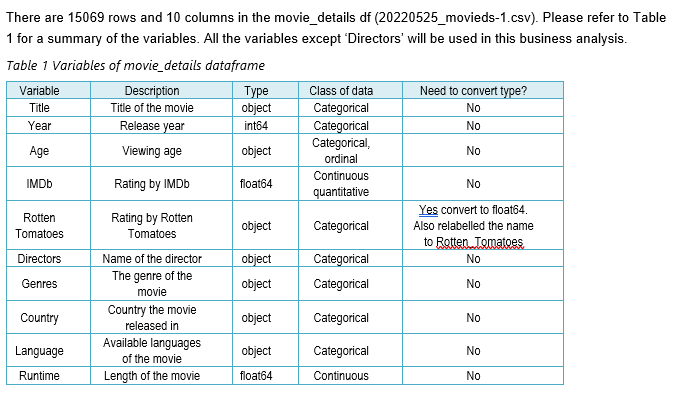

# C. Assess the quality of the data and rectify any issues
The quality of the dataset was reviewed including whether there were any missing values, dublicates, incorrect values and outliers

In [60]:
# Checked if all the columns 'Age', 'Genres', 'Country' and 'Language' have unique values and list them
movie_columns = ['Age', 'Genres', 'Country', 'Language' ]

for column in movie_columns:
    print(f"{column}: {movie_details[column].nunique()}")
    print(f"{column}: {movie_details[column].unique()}")

Age: 5
Age: [nan '18+' '13+' '16+' 'all' '7+']
Genres: 1794
Genres: ['Action,Adventure,Western' nan 'Horror,Mystery,Thriller' ...
 'Comedy,Romance,War' 'Action,Crime,Horror,Mystery,Sport'
 'Drama,Mystery,Thriller,Musical']
Country: 1204
Country: ['United States' nan 'United States,Hungary' ...
 'United States,Australia,Papua New Guinea,Poland,United Kingdom'
 'United States,Armenia' 'Austria,France']
Language: 1017
Language: ['English' nan 'Russian,German' ...
 'English,French,Tibetan,Mandarin,Russian,Hindi,Portuguese,Latin,Italian,Spanish'
 'Thai,Japanese' 'English,Italian,Arabic']


It seems that there are movies with more than one allocated Country, Language and Genre based on the number of unique values.

In [61]:
# Check if Title variable in movie_details df contains only unique values
movie_details.Title.nunique()

15069

In [62]:
movie_details.drop_duplicates()

,Title,Year,Age,IMDb,Rotten Tomatoes,Directors,Genres,Country,Language,Runtime
0,Trigger Pals,1939,NaN,5.3,NaN,Sam Newfield,"Action,Adventure,Western",United States,English,59.0
1,One Way Astronaut: The Mars One Initiative,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Open Grave,2013,18+,6.2,18%,Gonzalo López-Gallego,"Horror,Mystery,Thriller","United States,Hungary",English,102.0
3,Metallica: Kill 'Em All to St. Anger - The Ult...,2006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Beyond the Pale,2014,NaN,7.4,NaN,Ja-Ann Wang,"Short,Drama",United States,English,11.0
...,...,...,...,...,...,...,...,...,...,...
15064,Holiday Rush,2019,7+,4.8,NaN,Leslie Small,"Comedy,Romance",United States,English,92.0
15065,Demolition Man,1993,18+,6.7,59%,Marco Brambilla,"Action,Sci-Fi,Thriller",United States,English,115.0
15066,Düğün Dernek 2: Sünnet,2015,13+,6.4,NaN,Selçuk Aydemir,Comedy,Turkey,Turkish,112.0
15067,Fanney Khan,2018,NaN,4.5,63%,Atul Manjrekar,"Comedy,Drama,Music",India,NaN,130.0


There were no duplicate data as confirmed by the number of unique values for the ‘Title’ column and when performed the drop_duplicates no data was ‘dropped’ as there were still 15069 rows in the dataset.

In [63]:
#Renamed Rotten Tomatoes variable for ease of coding
movie_details.rename(columns={'Rotten Tomatoes': 'Rotten_Tomatoes'}, inplace = True)

#check renaming
print(movie_details.columns)

Index(['Title', 'Year', 'Age', 'IMDb', 'Rotten_Tomatoes', 'Directors',
       'Genres', 'Country', 'Language', 'Runtime'],
      dtype='object')


We would need to convert the rotten tomatoes ratings from an object to a number (float).

In [64]:
#convert rotten_tomatoes to a string 
movie_details['Rotten_Tomatoes'] = movie_details['Rotten_Tomatoes'].astype(str)

#convert string values in the Rotten_Tomatoes variable, by removing the %,
#then converting it to a float then dividing the values by 10, so the values are of a scale from 0 to 10.
movie_details['Rotten_Tomatoes'] = movie_details['Rotten_Tomatoes'].str.rstrip('%').astype('float') / 10.0

#check conversion
print(movie_details.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15069 entries, 0 to 15068
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Title            15069 non-null  object 
 1   Year             15069 non-null  int64  
 2   Age              6609 non-null   object 
 3   IMDb             14543 non-null  float64
 4   Rotten_Tomatoes  4636 non-null   float64
 5   Directors        14396 non-null  object 
 6   Genres           14814 non-null  object 
 7   Country          14672 non-null  object 
 8   Language         14507 non-null  object 
 9   Runtime          14533 non-null  float64
dtypes: float64(3), int64(1), object(6)
memory usage: 1.1+ MB
None


#### Check for missing values

In [65]:
movie_details.isnull().sum()

Title                  0
Year                   0
Age                 8460
IMDb                 526
Rotten_Tomatoes    10433
Directors            673
Genres               255
Country              397
Language             562
Runtime              536
dtype: int64

<Figure size 1000x600 with 0 Axes>

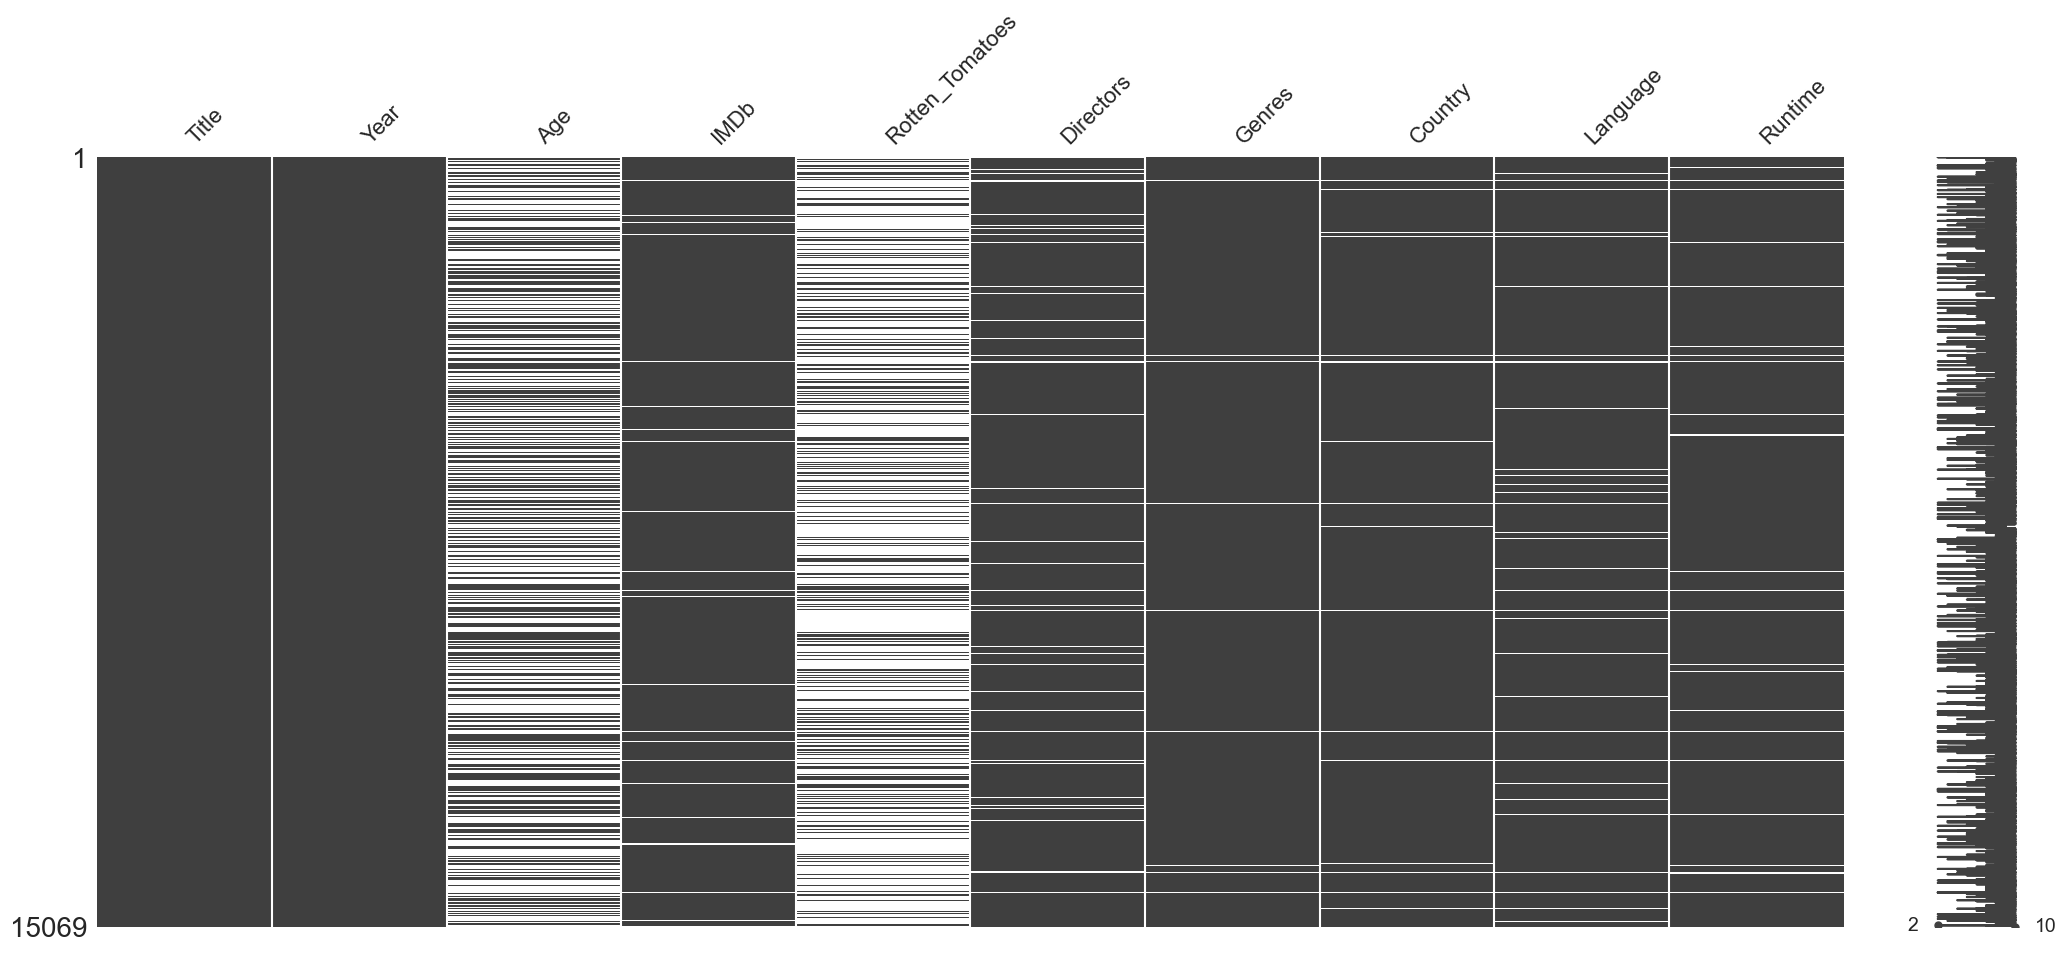

In [66]:
#Figure 1
plt.figure(figsize=(10, 6))
msno.matrix(movie_details)
plt.show()

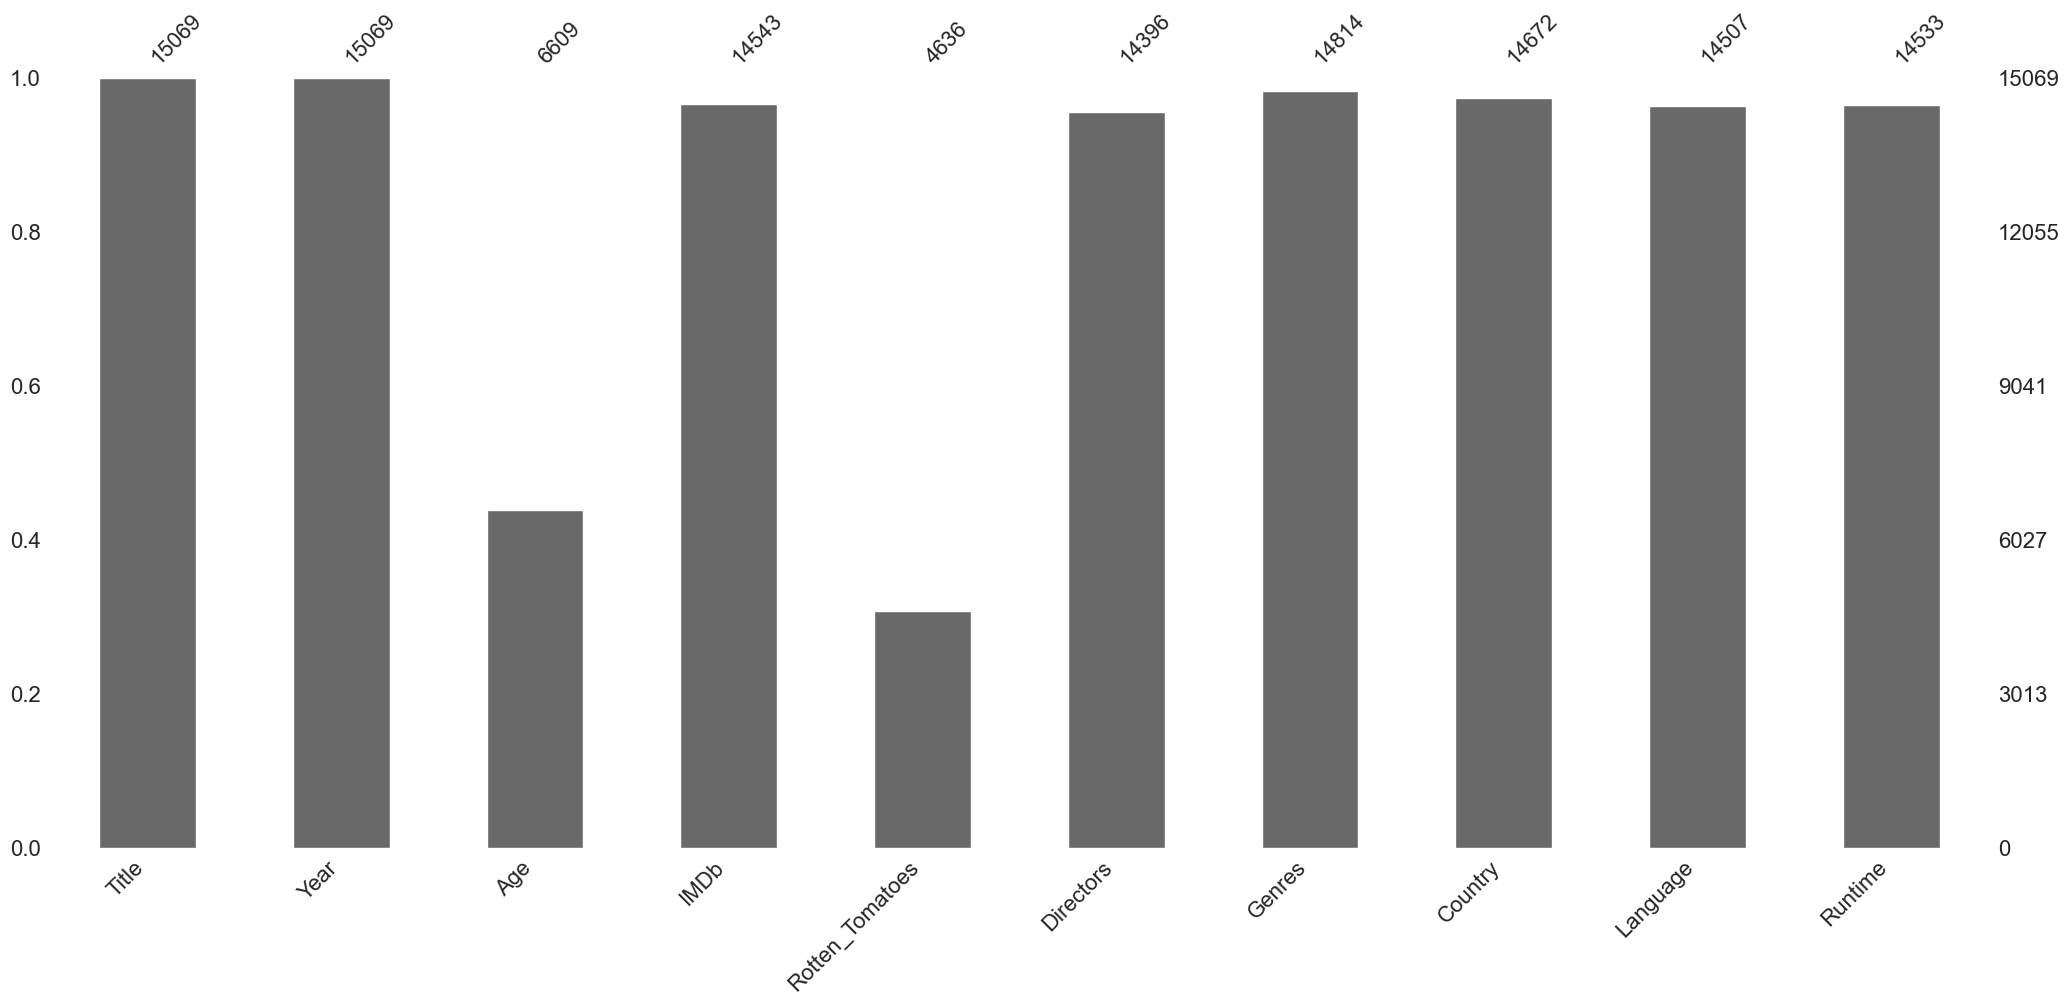

In [67]:
#Figure 2
#create all graphs so that has white background and includes ticks for Seaborn figures
sns.set_style("ticks")

#plot a bar chart showing number of missing values
plt.figure(figsize=(10, 6))
msno.bar(movie_details)
plt.show()

The Missingno library effectively visualises missing values. 
Of particular concern is the number of missing values for the Rotten Tomatoes rating (approximately 2/3 of the data), compared to the number of missing values in the IMDb rating scale. IMDb rating scale is well established and reliable rating scale for movies which has been shown to have a data distribution that is closer to normal than Rotten Tomatoes . Therefore, only IMDb rating scale was used in this business analysis. However, any missing data in the IMDb column was replaced with Rotten Tomatoes values.

In [68]:
# Replace missing values in the 'IMDb' column with the corresponding values from the 'Rotten_Tomatoes' column
# In the code, [:,'IMDb'] all the rows are selected in the column 'IMDb'. The .fillna code, fills any NaN (missing) values in the 
# 'IMDb' column with corresponding values in teh 'Rotten_Tomatoes column'.
movie_details.loc[:,'IMDb'] = movie_details['IMDb'].fillna(movie_details['Rotten_Tomatoes'])

#Check the number of null values.
movie_details.isnull().sum()

Title                  0
Year                   0
Age                 8460
IMDb                 524
Rotten_Tomatoes    10433
Directors            673
Genres               255
Country              397
Language             562
Runtime              536
dtype: int64

Only a couple of IMDb missing values were replaced by the Rotten_Tomatoes rating.

In [69]:
#Drop Rotten_Tomatoes dataframe as wont be required in the business analysis as will keep IMDb only
new_movie_details = movie_details.drop(columns = ['Rotten_Tomatoes'])

#View the dataframe
print(new_movie_details.shape)
new_movie_details.head()

(15069, 9)


,Title,Year,Age,IMDb,Directors,Genres,Country,Language,Runtime
0,Trigger Pals,1939,NaN,5.3,Sam Newfield,"Action,Adventure,Western",United States,English,59.0
1,One Way Astronaut: The Mars One Initiative,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Open Grave,2013,18+,6.2,Gonzalo López-Gallego,"Horror,Mystery,Thriller","United States,Hungary",English,102.0
3,Metallica: Kill 'Em All to St. Anger - The Ult...,2006,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Beyond the Pale,2014,NaN,7.4,Ja-Ann Wang,"Short,Drama",United States,English,11.0


Missing values in Runtime and IMDb values were deleted (as we have had enough data) to be able to answer the first two business questions. 

In [70]:
#We will drop missing values for IMDb and Runtime
new_movie_details2 = new_movie_details.dropna(subset=['IMDb', 'Runtime'])
new_movie_details2.isnull().sum()

Title           0
Year            0
Age          7730
IMDb            0
Directors     307
Genres         23
Country       101
Language      227
Runtime         0
dtype: int64

<Figure size 1000x600 with 0 Axes>

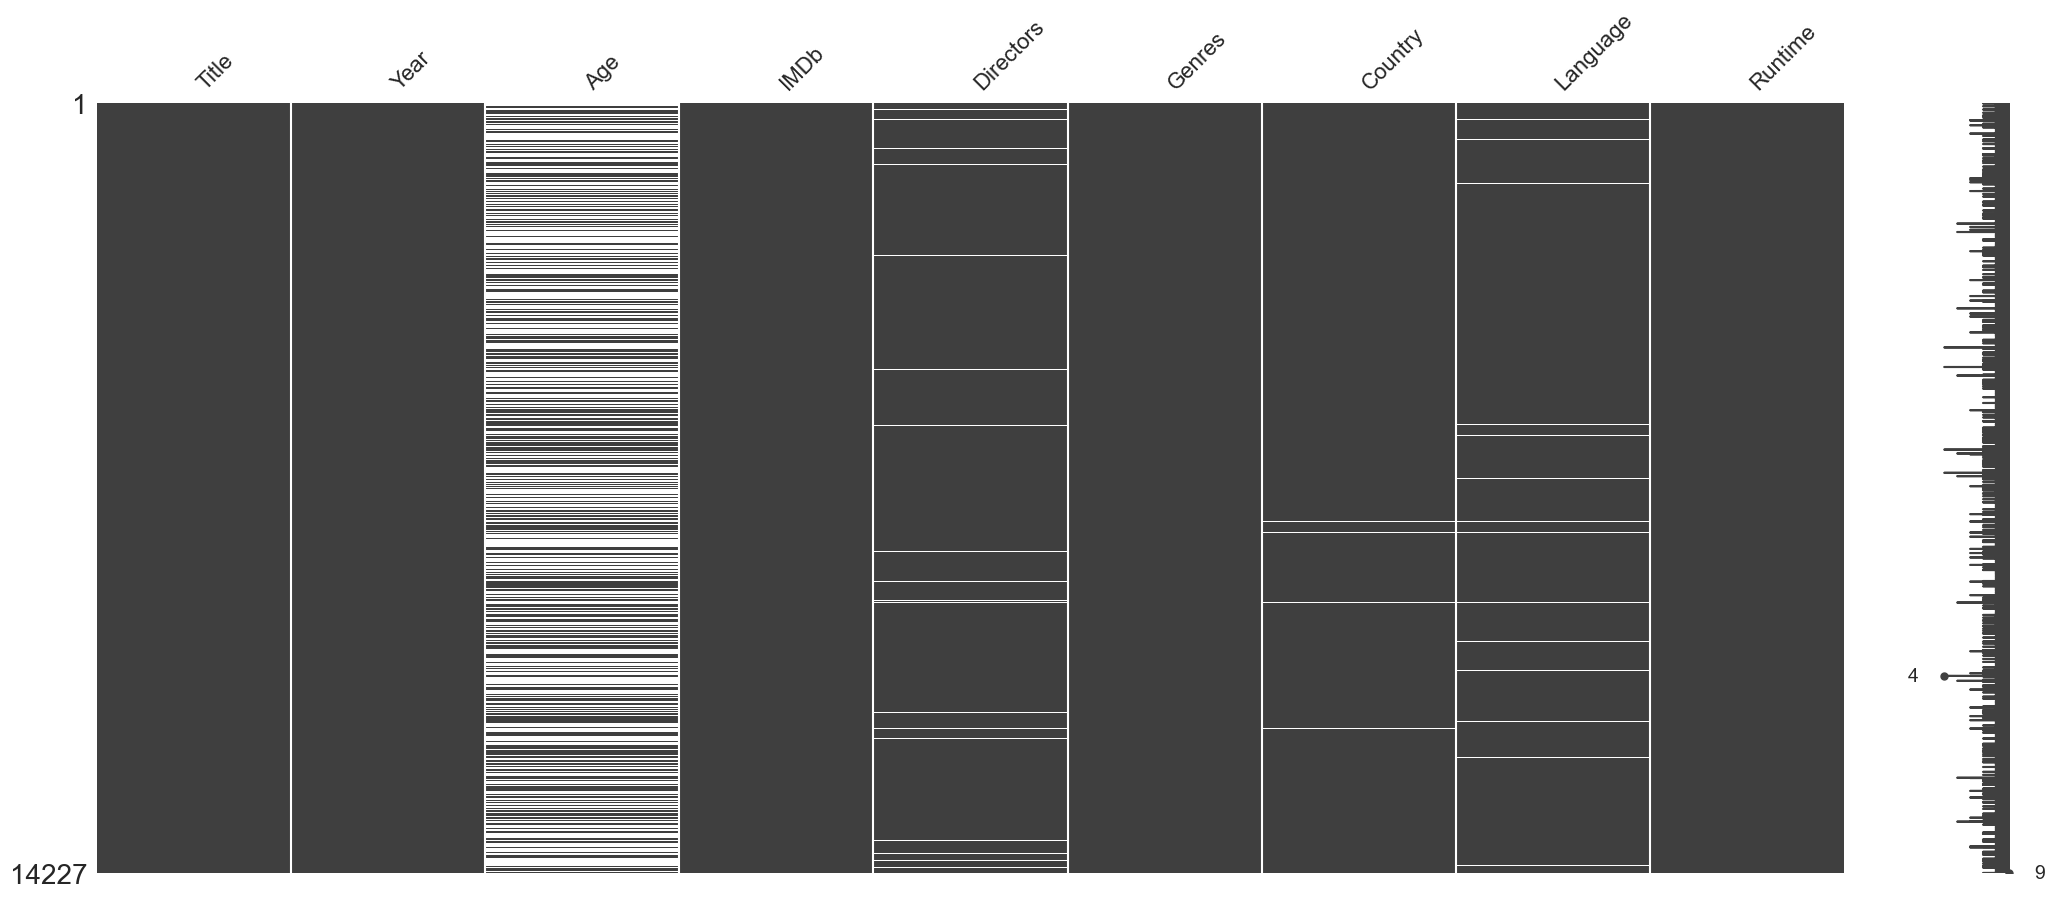

In [71]:
#Figure 3
plt.figure(figsize=(10, 6))
msno.matrix(new_movie_details2)
plt.show()

## Check for outliers by reviewing the distribution of IMDb and Runtime

In [72]:
# Compute descriptive statistics of movie_details to check outliers
# Round to two decimals.
new_movie_details2[['IMDb', 'Runtime']].describe().round(2)

,IMDb,Runtime
count,14227.00,14227.00
mean,5.91,93.79
std,1.35,28.28
min,0.00,1.00
25%,5.10,83.00
50%,6.10,92.00
75%,6.90,104.00
max,9.30,1256.00


For movies, the years ranged from 1913 to 2020. It was not expected to have movies included from 1913, so the data was sorted based on year and researched the first few movies to see if they existed. Found that they do, so doesn’t seem to be any anomalies of the data in the ‘Year’ column. However, there may be outliers for for Runtime with a maximum score of 1256, i.e., 20 hours long!
There doesnt seem to be any outliers for IMDb as the values ranged from 0 to 9.3, which is within the rating scale of the IMDb (0 to 10) where according the IMDb website: “1 meaning the title was terrible and one of the worst titles you've seen and 10 meaning you think it was excellent” 
Next will confirm outliers using distribution graphs. 
To check for outliers, histograms and boxplots were created for Runtime and IMDb scores. Matplotlib instead of just Seaborn was used to be able to label and arrange the plots side by side.

#### Runtime distributions

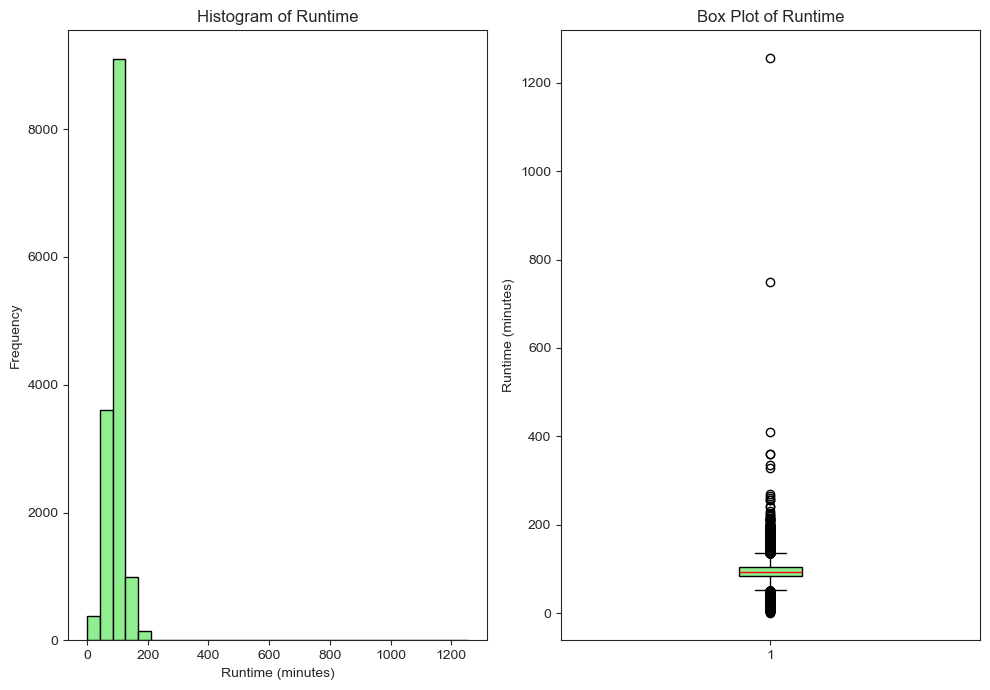

In [73]:
#Figure 4
# Create histogram and box plots using matplotlib
# Create a figure with 1 row and 2 columns of subplots
fig4, axes = plt.subplots(1, 2, figsize=(10, 7))

# Plot the histogram on the first subplot
axes[0].hist(new_movie_details2['Runtime'], bins=30, color='lightgreen', edgecolor='black')
axes[0].set_title("Histogram of Runtime")
axes[0].set_ylabel("Frequency")
axes[0].set_xlabel("Runtime (minutes)")

# Plot the box plot on the second subplot
axes[1].boxplot(new_movie_details2['Runtime'], vert= True, 
       patch_artist=True, 
       boxprops=dict(facecolor='lightgreen', color='black'), 
       medianprops=dict(color='red'))
axes[1].set_title("Box Plot of Runtime")
axes[1].set_ylabel("Runtime (minutes)")

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show(fig4)

The plot above shows several outliers for Runtime. Movies longer than 4 hours were filtered and checked for anomalies, revealing eight incorrect values. These were corrected and replaced in the dataframe as follows:

In [74]:
#list the movies that have a runtime greater than 240 min (4 hours) and check if correct
long_movies = new_movie_details2[new_movie_details2['Runtime']>240]
long_movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13 entries, 194 to 14406
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Title      13 non-null     object 
 1   Year       13 non-null     int64  
 2   Age        4 non-null      object 
 3   IMDb       13 non-null     float64
 4   Directors  6 non-null      object 
 5   Genres     12 non-null     object 
 6   Country    13 non-null     object 
 7   Language   13 non-null     object 
 8   Runtime    13 non-null     float64
dtypes: float64(2), int64(1), object(6)
memory usage: 1.0+ KB


In [75]:
#view the df
long_movies

,Title,Year,Age,IMDb,Directors,Genres,Country,Language,Runtime
194,The Vatican Museums,2007,NaN,5.0,Luca De Mata,NaN,Italy,English,410.0
2166,Law of the Lawless,1964,NaN,6.1,NaN,"Action,Crime,Drama",Russia,Russian,750.0
4104,The 25th Anniversary Rock and Roll Hall of Fam...,2009,NaN,8.7,Joel Gallen,Music,United States,English,255.0
5545,Scarlett,2016,16+,4.4,NaN,"Drama,Romance","France,United States,Germany,Italy,United King...",English,360.0
7193,Colorado,1940,all,5.9,NaN,"Action,Adventure,Drama,Romance,Western",United States,English,1256.0
8812,Foods That Cure Disease,2018,NaN,5.5,Craig McMahon,Documentary,United States,English,256.0
9836,Dina,2017,NaN,6.8,NaN,"Adventure,Drama,Fantasy,Sci-Fi","United States,Canada,Germany,Italy","English,Italian",265.0
10228,Gone,2012,13+,5.9,NaN,"Drama,Mystery",United Kingdom,English,270.0
10657,The Greatest Story Ever Told,1965,all,6.6,"George Stevens,David Lean,Jean Negulesco","Biography,Drama,History",United States,English,260.0
12624,The Inner Circle,2009,NaN,6.6,NaN,Drama,Sweden,Swedish,360.0


There are 13 movies that have a runtime greater than 4 hrs. The dataframe was saved and each movie was checked for correct runtime.

In [76]:
#save long movies and check run times
long_movies.to_csv('long_movies.csv')

Eight movies were found to have incorrect runtimes when researched online. 

In [77]:
#movies with incorrect Runtime values are as follows:
'''Carlos el terrorista
Colorado
Dina
Gone
Law of the Lawless
Scarlett
The Inner Circle
Incorrrect and correct runtime
334	97
1256 57
265	103
270	94
750	87
360	92
360	96
'''

#create code to replace incorrect values with the correct values
#new_movie_details
# Dictionary of titles and their incorrect to correct runtime values
corrections = {'Carlos el terrorista':{334:97},
                'Colorado':{1256:57},
                'Dina':{265:103},
                'Gone':{270:94},
                'Law of the Lawless':{750:87},
                'Scarlett':{360:92},
                'The Inner Circle':{360:96}}

#loop to replace values
for title, runtime_corrections in corrections.items():
    for incorrect_value, correct_value in runtime_corrections.items():
        new_movie_details2.loc[(new_movie_details2['Title']==title) & (new_movie_details2['Runtime']==incorrect_value), 
        'Runtime']=correct_value

In [78]:
new_movie_details2[['IMDb', 'Runtime']].describe().round(2)

,IMDb,Runtime
count,14227.00,14227.00
mean,5.91,93.58
std,1.35,25.62
min,0.00,1.00
25%,5.10,83.00
50%,6.10,92.00
75%,6.90,104.00
max,9.30,410.00


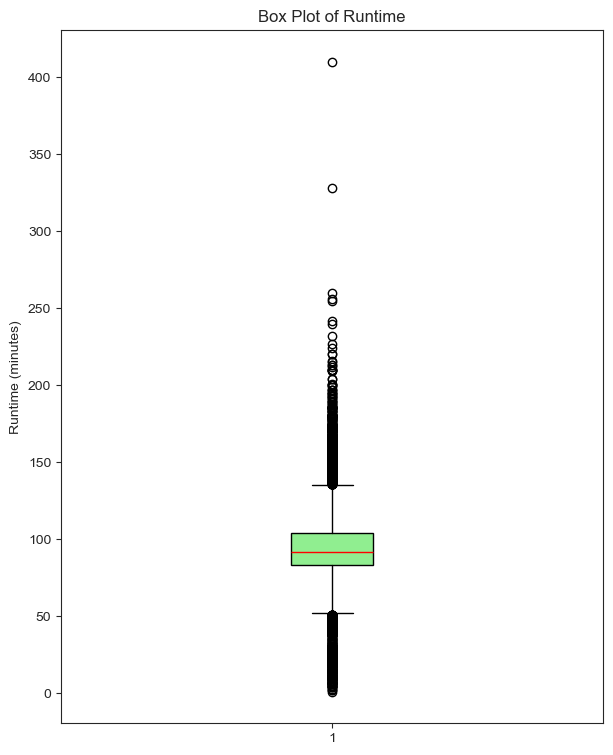

In [79]:
#Figure 5
#create a Runtime distribution via box plot as want to see if runtimes have been corrrected (Matplotlib)
# Create a figure and axes object
fig5, ax = plt.subplots(figsize=(7, 9))


#create plot
ax.boxplot(new_movie_details2['Runtime'], vert= True, 
       patch_artist=True, 
       boxprops=dict(facecolor='lightgreen', color='black'), 
       medianprops=dict(color='red'))

ax.set_title("Box Plot of Runtime")
ax.set_ylabel("Runtime (minutes)")

#show plot
plt.show(fig5)


From the above plot and descriptive statistics we have replaced the incorrect values.

### IMDb distribution

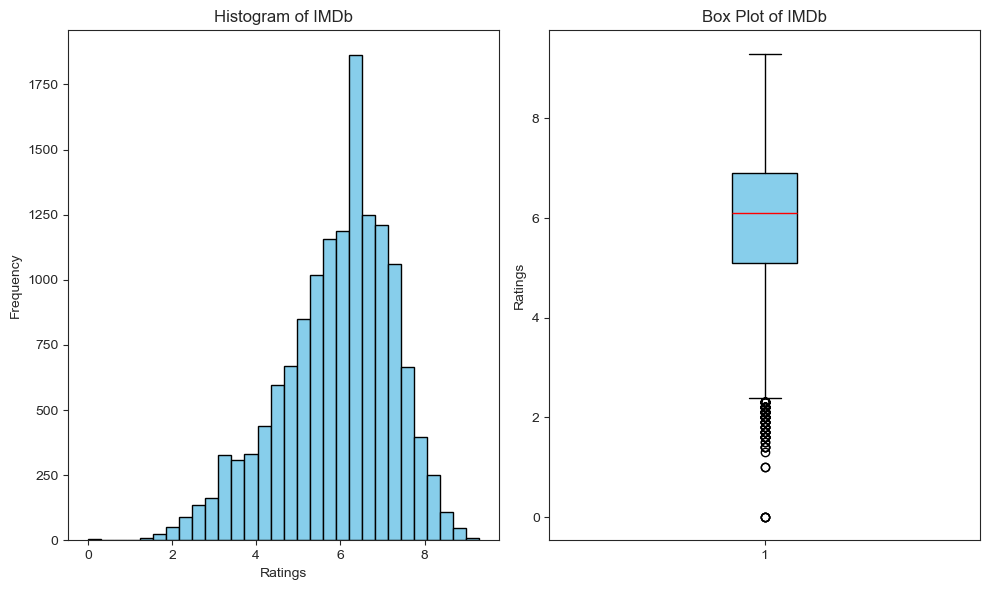

In [80]:
#Figure 6
# Create a figure and axes object
fig6, axes = plt.subplots(1, 2, figsize=(10, 6))

# Plot the histogram on the first subplot
axes[0].hist(new_movie_details2['IMDb'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Histogram of IMDb')
axes[0].set_ylabel('Frequency')
axes[0].set_xlabel('Ratings')

# Plot the boxplot on the first subplot
axes[1].boxplot(new_movie_details2['IMDb'], vert= True, 
       patch_artist=True, 
       boxprops=dict(facecolor='skyblue', color='black'), 
       medianprops=dict(color='red'))
axes[1].set_title('Box Plot of IMDb')
axes[1].set_ylabel('Ratings')


# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show(fig6)

The plots confirmed that there were no outliers for IMDb rating as the values ranged from 0 to 9.3, which is within the rating scale of the IMDb (0 to 10) where according the IMDb website: “1 meaning the title was terrible and one of the worst titles you've seen and 10 meaning you think it was excellent” .

new_movie_details2 is the cleaned dataframe that has corrected for Runtime anamalies and have deleted missing values for IMDb and Runtime.


# D. Performing analyses to address the business goals

In [81]:
#create a copy of new_movies_details2 so that can try different methods
new_movie_details3 = new_movie_details2.copy()

## 1. Does France make longer movies on average based on the runtime?

Will use two methods to answer this question:

**Method 1** uses the Country column and assumes the first country provided is where the movie has been made.

**Method 2** uses the Language column and Filters for french language and non-french language movies.


### Method 1 using new_movies_details3

In [82]:
#need to split 'country'  and call first country the primary country to compare movie lengths per country
#create a lambda function that splits the string value by commas and selects the first element
# If there is a NaN value, fill it with a NaN value
f1=lambda x:x.split(',')[0] if isinstance(x, str) else None

#create a new column called 'Primary_country' in the movie_details then apply the f1 function to split the 'country' column to
# include only the first genre in the column.
new_movie_details3.loc[:,'Primary_Country'] = new_movie_details3['Country'].apply(f1)

#review the dataframe
print(new_movie_details3.shape)
new_movie_details3.head()

(14227, 10)


,Title,Year,Age,IMDb,Directors,Genres,Country,Language,Runtime,Primary_Country
0,Trigger Pals,1939,NaN,5.3,Sam Newfield,"Action,Adventure,Western",United States,English,59.0,United States
2,Open Grave,2013,18+,6.2,Gonzalo López-Gallego,"Horror,Mystery,Thriller","United States,Hungary",English,102.0,United States
4,Beyond the Pale,2014,NaN,7.4,Ja-Ann Wang,"Short,Drama",United States,English,11.0,United States
5,White Tiger,1996,13+,5.0,Karen Shakhnazarov,"Action,Adventure,Fantasy,War",Russia,"Russian,German",104.0,Russia
6,Path to War,2002,16+,7.3,John Frankenheimer,"Biography,Drama,War",United States,English,165.0,United States


In [83]:
#number of unique values of primary_country
print(f"{'Number of primary countries'}: {new_movie_details3.Primary_Country.nunique()}")
print(f"{'List of unique primary countries'}: {new_movie_details3.Primary_Country.unique()}")

Number of primary countries: 116
List of unique primary countries: ['United States' 'Russia' 'Denmark' 'United Kingdom' 'Mexico' 'Sweden'
 'Hong Kong' 'Canada' 'Czech Republic' 'South Africa' 'France' 'Australia'
 'South Korea' 'India' 'Spain' 'Egypt' None 'Germany' 'Taiwan'
 'Isle Of Man' 'Japan' 'Greece' 'Italy' 'Ireland' 'Turkey' 'Israel'
 'Indonesia' 'Uruguay' 'Nigeria' 'Argentina' 'Soviet Union' 'China'
 'Colombia' 'Cuba' 'Belgium' 'Netherlands' 'Bahamas' 'Brazil' 'Malaysia'
 'New Zealand' 'Estonia' 'Thailand' 'Norway' 'Iraq' 'Pakistan' 'Romania'
 'Austria' 'Guatemala' 'Switzerland' 'Slovakia' 'Bosnia and Herzegovina'
 'Yugoslavia' 'Bulgaria' 'Saudi Arabia' 'Bangladesh' 'Philippines' 'Chile'
 'Hungary' 'Belarus' 'West Germany' 'Iceland' 'Mongolia' 'Nepal'
 'Singapore' 'Latvia' 'Croatia' 'Lithuania' 'Afghanistan' 'Finland' 'Peru'
 'Malta' 'Czechoslovakia' 'Republic of North Macedonia' 'Luxembourg'
 'Iran' 'Albania' 'Rwanda' 'Cambodia' 'United Arab Emirates' 'Portugal'
 'Serbia' 'Gh

There are 116 seperate primary countries

In [84]:
#obtain the statistics for IMDb and Runtime
new_movie_details3[['IMDb', 'Runtime']].describe().round(2)


,IMDb,Runtime
count,14227.00,14227.00
mean,5.91,93.58
std,1.35,25.62
min,0.00,1.00
25%,5.10,83.00
50%,6.10,92.00
75%,6.90,104.00
max,9.30,410.00


#### Average runtime for all movies is 93.6 min and average IMDb scores is 5.91

#### Determine averages for France only

In [85]:
#Average runtime and IMDb for france only
france_movies = new_movie_details3[new_movie_details3['Primary_Country'] == 'France']

# Calculate the mean runtime & IMDb for France
france_count = france_movies['Title'].count()
france_runtime_avg = france_movies['Runtime'].mean().round(2)
france_IMDb_avg = france_movies['IMDb'].mean().round(2)

# Display the result
print(f"{'Number of movies made in France'}: {france_movies.Title.count()}")
print(f"{'Average runtime for movies made in France'}: {france_movies.Runtime.mean().round(2)}")
print(f"{'Average IMDb score for movies made in France'}: {france_movies.IMDb.mean().round(2)}")



Number of movies made in France: 304
Average runtime for movies made in France: 97.45
Average IMDb score for movies made in France: 6.33


#### Averages for each country

In [86]:
#average movies per country
country_runtime_avg = new_movie_details3.groupby('Primary_Country')['Runtime'].mean().reset_index(name='Mean Runtime')
#view table
country_average = country_runtime_avg.sort_values('Mean Runtime', ascending=False)
country_average.head(50)

,Primary_Country,Mean Runtime
16,Cambodia,136.000000
43,India,135.498406
73,Pakistan,128.388889
90,Slovakia,118.500000
92,Somalia,116.000000
75,Papua New Guinea,116.000000
63,Malta,114.000000
44,Indonesia,113.000000
94,South Korea,111.444444
10,Bangladesh,111.333333


By determining the average runtimes for each country I am able to determine where France is placed with regard to other countries.

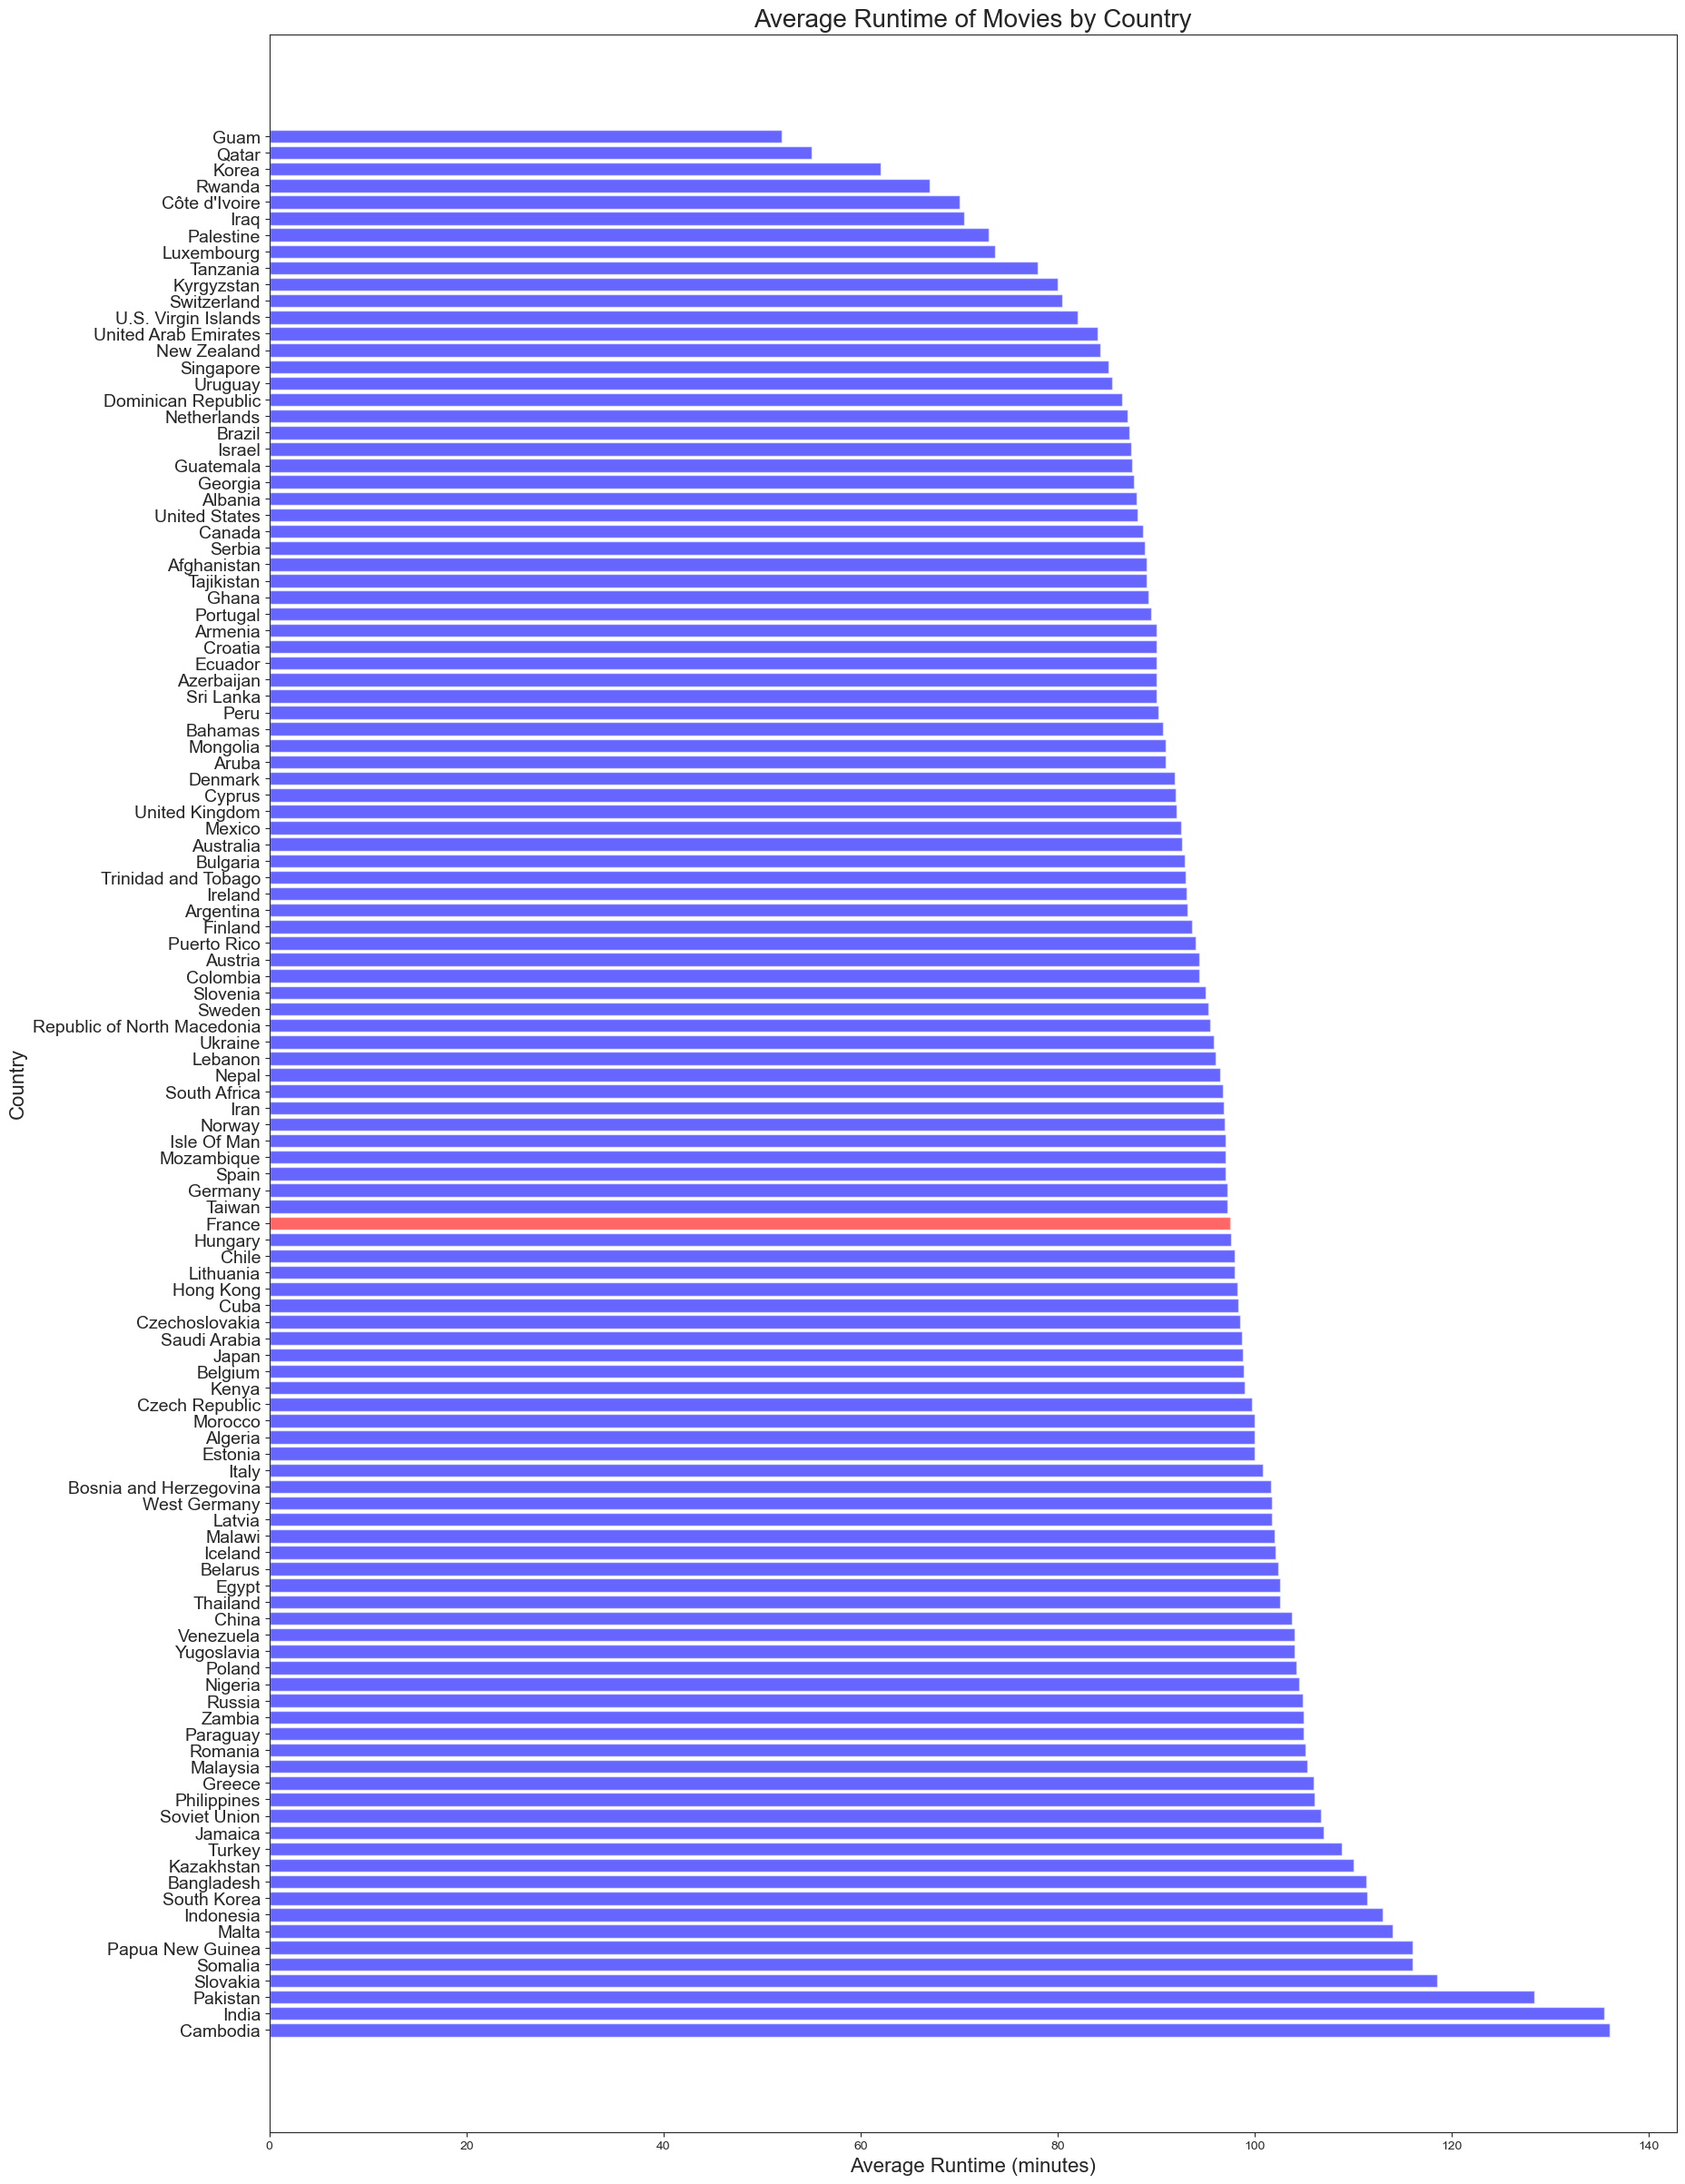

In [87]:
#Figure 7
# Create a figure and axes object
fig7, ax = plt.subplots(figsize=(20, 30))


# Define colors based on the country
colors = ['r' if country == 'France' else 'b' for country in country_average['Primary_Country']]

#create plot
ax.barh(country_average['Primary_Country'], country_average['Mean Runtime'], color=colors, alpha=0.6)
ax.set_title('Average Runtime of Movies by Country', fontsize=20)
ax.set_ylabel('Country', fontsize=16)
ax.set_xlabel('Average Runtime (minutes)', fontsize=16)
ax.tick_params(axis='y', labelsize=14)

#show plot
plt.show(fig7)


**Note:** Will provide Method 2 after answering Method 1 for Q2 as well

## 2. Does France make better movies on average based on the ratings?

### Method 1 using new_movies_details3

In [88]:
#average IMDb rating per country
country_IMDb_avg = new_movie_details3.groupby('Primary_Country')['IMDb'].mean().reset_index(name='Mean IMDb')
#view table
country_IMDb_avg = country_IMDb_avg.sort_values('Mean IMDb', ascending=False)
country_IMDb_avg

,Primary_Country,Mean IMDb
92,Somalia,8.8
38,Guam,8.3
28,Dominican Republic,7.8
68,Nepal,7.7
25,Czechoslovakia,7.7
...,...,...
55,Korea,4.7
59,Lithuania,4.7
66,Morocco,4.7
5,Aruba,4.1


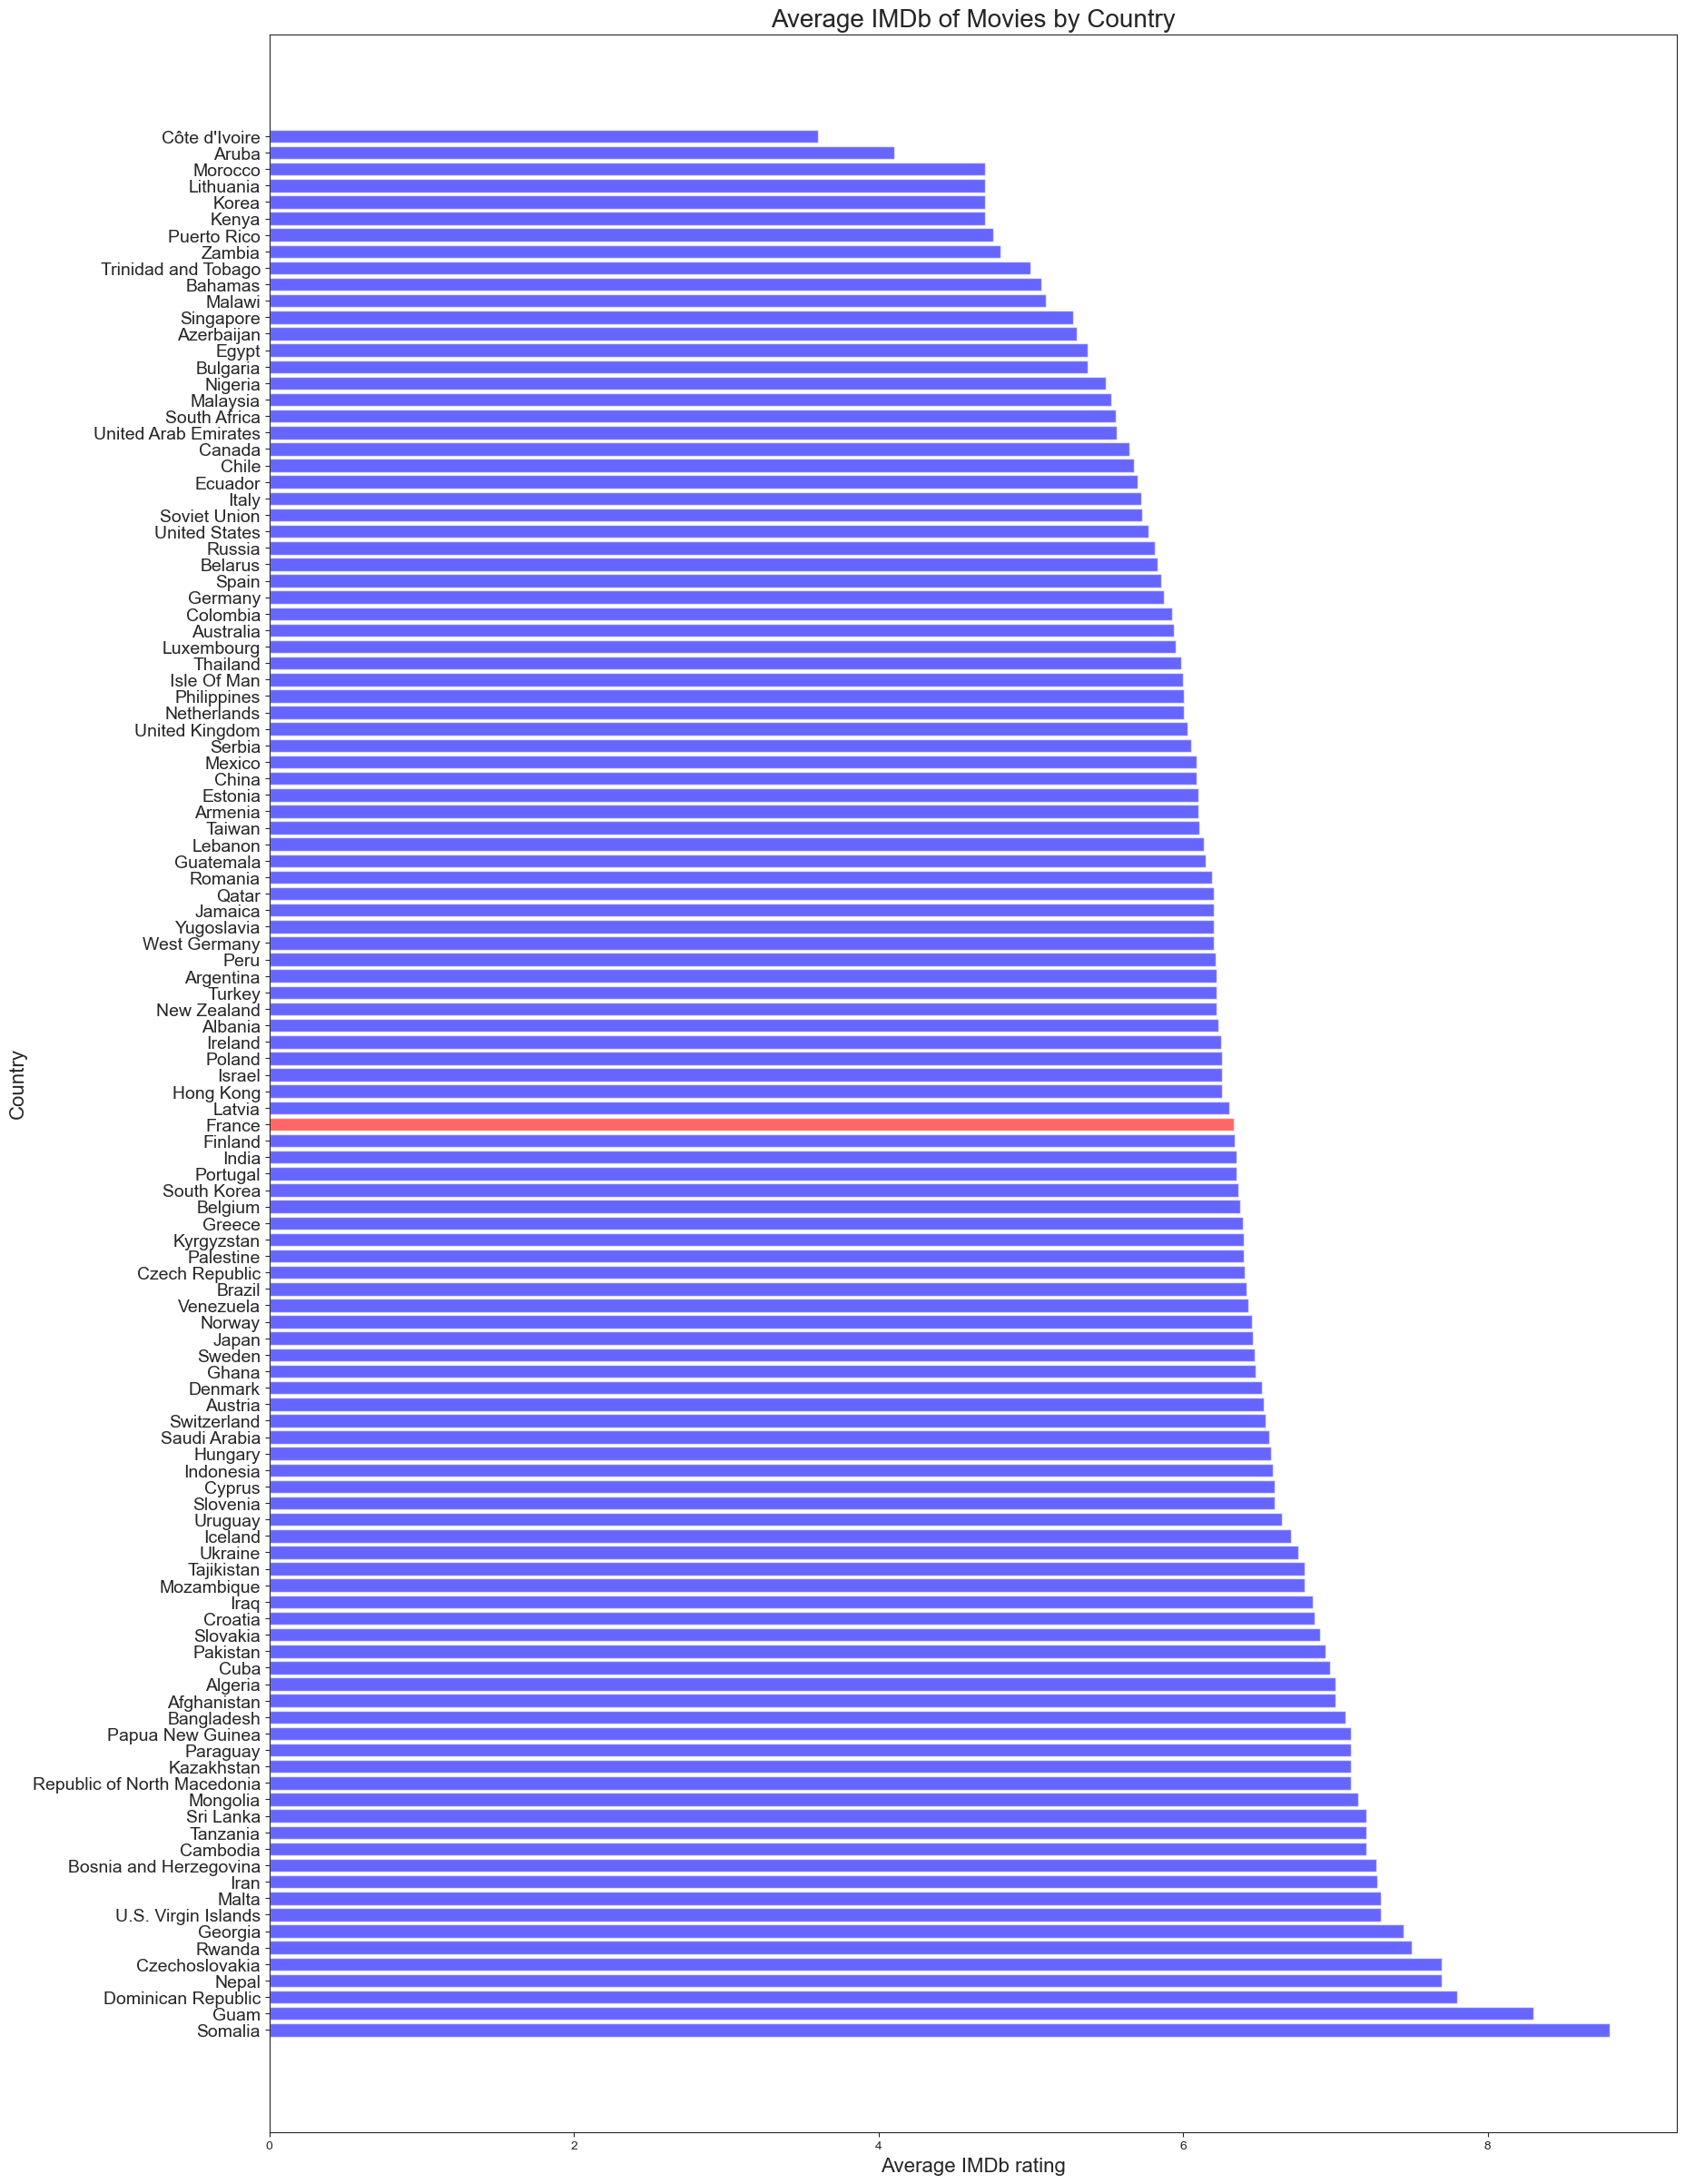

In [89]:
#Figure 8
# Create a figure and axes object using Matplotlib
fig8, ax = plt.subplots(figsize=(20, 30))

# Define colors based on the country
colors = ['r' if country == 'France' else 'b' for country in country_IMDb_avg['Primary_Country']]


#create plot
ax.barh(country_IMDb_avg['Primary_Country'], country_IMDb_avg['Mean IMDb'], color=colors, alpha=0.6)

#label plot
ax.set_title('Average IMDb of Movies by Country', fontsize=20)
ax.set_ylabel('Country', fontsize=16)
ax.set_xlabel('Average IMDb rating', fontsize=16)
ax.tick_params(axis='y', labelsize=14)

#show plot
plt.show(fig8)

## Method 2 for Q1 & Q2
This time filtered for french language movies instead of using the primary country assumption as in Method 1

In [90]:
#filtered french language movies (created a new dataframe called movie_details_french based on the clean dataframe new_movie_details2)
movie_details_french = new_movie_details2[new_movie_details2['Language'].str.contains('french', case=False, na=False)]

#review the movie_details_french df to check that includes french language movies only
print(movie_details_french.info())
movie_details_french.head()

<class 'pandas.core.frame.DataFrame'>
Index: 702 entries, 31 to 15063
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Title      702 non-null    object 
 1   Year       702 non-null    int64  
 2   Age        342 non-null    object 
 3   IMDb       702 non-null    float64
 4   Directors  696 non-null    object 
 5   Genres     702 non-null    object 
 6   Country    702 non-null    object 
 7   Language   702 non-null    object 
 8   Runtime    702 non-null    float64
dtypes: float64(2), int64(1), object(6)
memory usage: 54.8+ KB
None


,Title,Year,Age,IMDb,Directors,Genres,Country,Language,Runtime
31,Mystery of the Pink Dolphin,2015,NaN,7.1,Eric Ellena,Documentary,"France,Brazil","French,English,Portuguese,Dutch",52.0
49,My Revolution,2016,NaN,3.5,Ramzi Ben Sliman,Drama,France,French,80.0
54,The Story of the Twelve Apostles,1999,NaN,6.6,Yanai Arfi,"Documentary,Short",United States,"English,French,Spanish",26.0
78,Girl on a Bicycle,2013,18+,6.2,Jeremy Leven,"Comedy,Drama,Romance","Germany,France","English,French,German,Italian",101.0
109,Razzia,2018,NaN,6.2,Rose Bosch,"Drama,History,War","France,Germany,Hungary","French,German,Yiddish",115.0


In [91]:
print(movie_details_french[['IMDb', 'Runtime']].describe().round(2))
movie_details_french.isnull().sum()

         IMDb  Runtime
count  702.00   702.00
mean     6.37   100.83
std      1.01    23.00
min      2.30    13.00
25%      5.90    90.00
50%      6.50   100.00
75%      7.10   113.00
max      8.80   195.00


Title          0
Year           0
Age          360
IMDb           0
Directors      6
Genres         0
Country        0
Language       0
Runtime        0
dtype: int64

There are 702 movies that have a french language, with average IMDb scores=6.37 and average runtime=100.83. When we compare this to method 1 (Made in France) we had 304 made in France with average IMDb score =6.33 and Average runtime= 97.4. There is very little difference with IMDb scores, however average runtime was slightly higher using method 2.

In [92]:
#filtered non-french language movies
movie_details_non_french = new_movie_details2[~new_movie_details2['Language'].str.contains('french', case=False, na=False)]


#review the movie_details_french df to check that does not include french language movies only
print(movie_details_non_french.info())
movie_details_non_french.head()

<class 'pandas.core.frame.DataFrame'>
Index: 13525 entries, 0 to 15068
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Title      13525 non-null  object 
 1   Year       13525 non-null  int64  
 2   Age        6155 non-null   object 
 3   IMDb       13525 non-null  float64
 4   Directors  13224 non-null  object 
 5   Genres     13502 non-null  object 
 6   Country    13424 non-null  object 
 7   Language   13298 non-null  object 
 8   Runtime    13525 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 1.0+ MB
None


,Title,Year,Age,IMDb,Directors,Genres,Country,Language,Runtime
0,Trigger Pals,1939,NaN,5.3,Sam Newfield,"Action,Adventure,Western",United States,English,59.0
2,Open Grave,2013,18+,6.2,Gonzalo López-Gallego,"Horror,Mystery,Thriller","United States,Hungary",English,102.0
4,Beyond the Pale,2014,NaN,7.4,Ja-Ann Wang,"Short,Drama",United States,English,11.0
5,White Tiger,1996,13+,5.0,Karen Shakhnazarov,"Action,Adventure,Fantasy,War",Russia,"Russian,German",104.0
6,Path to War,2002,16+,7.3,John Frankenheimer,"Biography,Drama,War",United States,English,165.0


#### There are 13525 movies that don't have a french language 


In [93]:
#view the descriptive statistics for IMDb and Runtime & null values for non-french language movies
print(movie_details_non_french[['IMDb', 'Runtime']].describe().round(2))
movie_details_non_french.isnull().sum()

           IMDb   Runtime
count  13525.00  13525.00
mean       5.88     93.21
std        1.36     25.69
min        0.00      1.00
25%        5.10     82.00
50%        6.10     92.00
75%        6.90    104.00
max        9.30    410.00


Title           0
Year            0
Age          7370
IMDb            0
Directors     301
Genres         23
Country       101
Language      227
Runtime         0
dtype: int64

Average runtime for non-french language movies = 93.21
Average IMDb score for non-french language movies = 5.88

In [94]:
#Figure 9
#create side by side plots using Bokeh to compare average IMDb scores and average runtimes between french and non-french movies.

#import what I need for the layout in Bokeh
from bokeh.layouts import row

# View the output in notebook
output_notebook()


#Create the dataset of Average IMDb & Average Runtimes based on the values above
Language = ['French-language movies', 'Non-French language movies']
IMDb = [6.37, 5.88]
Runtime = [100.83, 93.21]

#Set the colours of the bars
colors = ['#ED7D31', '#4472C4']

#Specify the figures
IMDb_plot = figure(x_range=Language,
                  width=500,
                  height=600,
                  y_axis_label='Average IMDb Rating',
                  title='Average IMDb Rating for French and non-French movies')

Runtime_plot = figure(x_range=Language,
                  width=500,
                  height=600,
                  y_axis_label='Average Runtimes',
                  title='Average Runtimes for French and non-French movies')

# Change the x-axis major label font size
IMDb_plot.xaxis.major_label_text_font_size = '10pt'
Runtime_plot.xaxis.major_label_text_font_size = '10pt'

#create the bar plots
IMDb_plot.vbar(x=Language, top=IMDb, width=0.5, color=colors)
Runtime_plot.vbar(x=Language, top=Runtime, width=0.5, color=colors)

#Arrange plots into a single row
fig9 = row(IMDb_plot, Runtime_plot)

#Show the plot
show(fig9)


Loading BokehJS ...

Overall using Method 1 we can see from the distribution that France was placed in the middle of the distribution compared to other countries with regard to the average IMDb scores and average runtime movies. However, when using Method 2, we are able to compare movies that that have french-language and all movies that are non-french language. As we can see from the graph created by Bokeh, french-language movies have on average greater IMDb ratings than non-french language and also greater on average runtimes than non-french language movies. 

From this observation it would seem that the longer the movie, the higher the IMDb rating. We will investigate this by creating a correlation between IMDb and Runtime. Please refer to Q6 below.

## 3. Are there any French movies that claim to be of more than one genre? 

Will use two methods to answer this question:

**Method 1** using the split method to split the genres and count the number of genres per movie only

**Method 2** using the explode method to split the genres into separate rows then use groupby to count number of genres per movie


### Method 1 using split method

In [95]:
# Used the movie_details_french which only has french language movies
#first make a copy 
movie_details_french_genres = movie_details_french.copy()

#confirm that there are no missing values for Genre for movie_details_french_genres/movie_details_french
movie_details_french_genres.isnull().sum()

Title          0
Year           0
Age          360
IMDb           0
Directors      6
Genres         0
Country        0
Language       0
Runtime        0
dtype: int64

In [96]:
#create a new column called Genre_count, lamba function splits the genres via commas and counts the number of genres
movie_details_french_genres['genre_number'] = movie_details_french_genres['Genres'].apply(lambda x: len(x.split(',')))

#number & type of unique occurances of 'genre_count'
print(f"{"Genre Count Number of Unique Values"}: {movie_details_french_genres.genre_number.nunique()}")
print(f"{"Genre Count Unique Values"}: {movie_details_french_genres.genre_number.unique()}")

Genre Count Number of Unique Values: 8
Genre Count Unique Values: [1 2 3 4 5 8 6 7]


The number of genres per movie ranged from 1 to 8.

In [97]:
#Creates df genre_count that counts the occurrance of each unique value 'Genre_count column'
genre_count = movie_details_french_genres['genre_number'].value_counts().reset_index(name='genre_count')

#view genre_count
genre_count.sort_values('genre_number')

,genre_number,genre_count
2,1,164
0,2,195
1,3,180
3,4,99
4,5,43
5,6,13
6,7,5
7,8,3


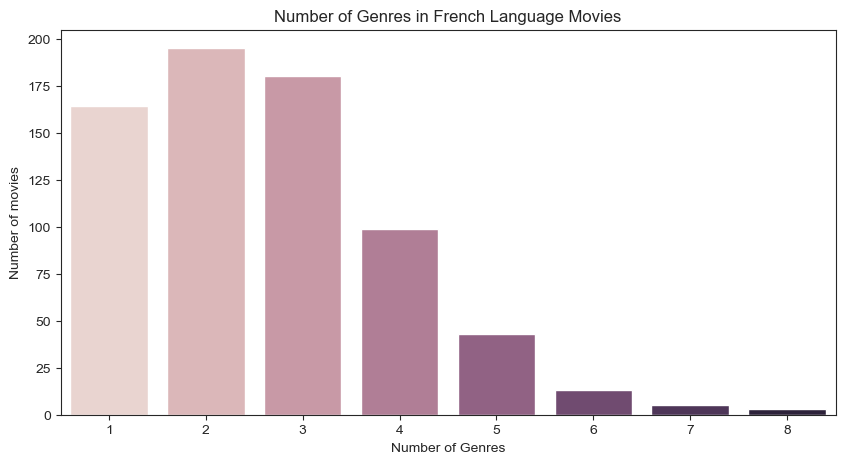

In [98]:
#Figure 10
#create a distribution graph of means using seaborn
# Create a figure and axes object
fig10, ax = plt.subplots(figsize=(10, 5))

#create plot
ax=sns.barplot(
    data=genre_count,
    x='genre_number',
    y='genre_count',
    hue='genre_number',
    legend=False)

#set the lable and title
ax.set(xlabel='Number of Genres', ylabel='Number of movies', title='Number of Genres in French Language Movies')

#show the plot
plt.show(fig10)


### Method 2 using explode function

In [99]:
# Use the movie_details_french which only has french language movies
#make a copy
movie_details_french2 = movie_details_french.copy()

# Split the genres into a list in the 'Genres' column
movie_details_french2['Genres'] = movie_details_french2['Genres'].str.split(',')
#view movies_details_french
movie_details_french2

,Title,Year,Age,IMDb,Directors,Genres,Country,Language,Runtime
31,Mystery of the Pink Dolphin,2015,NaN,7.1,Eric Ellena,[Documentary],"France,Brazil","French,English,Portuguese,Dutch",52.0
49,My Revolution,2016,NaN,3.5,Ramzi Ben Sliman,[Drama],France,French,80.0
54,The Story of the Twelve Apostles,1999,NaN,6.6,Yanai Arfi,"[Documentary, Short]",United States,"English,French,Spanish",26.0
78,Girl on a Bicycle,2013,18+,6.2,Jeremy Leven,"[Comedy, Drama, Romance]","Germany,France","English,French,German,Italian",101.0
109,Razzia,2018,NaN,6.2,Rose Bosch,"[Drama, History, War]","France,Germany,Hungary","French,German,Yiddish",115.0
...,...,...,...,...,...,...,...,...,...
15043,Among Dead Men,2008,18+,4.0,James Richards,"[Action, Crime, Horror, Mystery, Sport]",Australia,"English,French,Spanish",94.0
15051,The Special Relationship,2010,16+,6.7,Richard Loncraine,"[Biography, Drama, History]","United Kingdom,United States","English,French",93.0
15058,The Decline,2020,NaN,5.9,Patrice Laliberté,[Thriller],Canada,French,83.0
15060,Michael H. – Profession: Director,2013,13+,7.0,Yves Montmayeur,"[Documentary, Biography]","Austria,France","German,French",92.0


In [100]:
#explode the lists in the genres column into rows
exploded_frenchmovies_genres = movie_details_french2.explode('Genres')

#view the df
exploded_frenchmovies_genres

,Title,Year,Age,IMDb,Directors,Genres,Country,Language,Runtime
31,Mystery of the Pink Dolphin,2015,NaN,7.1,Eric Ellena,Documentary,"France,Brazil","French,English,Portuguese,Dutch",52.0
49,My Revolution,2016,NaN,3.5,Ramzi Ben Sliman,Drama,France,French,80.0
54,The Story of the Twelve Apostles,1999,NaN,6.6,Yanai Arfi,Documentary,United States,"English,French,Spanish",26.0
54,The Story of the Twelve Apostles,1999,NaN,6.6,Yanai Arfi,Short,United States,"English,French,Spanish",26.0
78,Girl on a Bicycle,2013,18+,6.2,Jeremy Leven,Comedy,"Germany,France","English,French,German,Italian",101.0
...,...,...,...,...,...,...,...,...,...
15051,The Special Relationship,2010,16+,6.7,Richard Loncraine,History,"United Kingdom,United States","English,French",93.0
15058,The Decline,2020,NaN,5.9,Patrice Laliberté,Thriller,Canada,French,83.0
15060,Michael H. – Profession: Director,2013,13+,7.0,Yves Montmayeur,Documentary,"Austria,France","German,French",92.0
15060,Michael H. – Profession: Director,2013,13+,7.0,Yves Montmayeur,Biography,"Austria,France","German,French",92.0


By exploding it has increased the number rows to 1842.

In [101]:
#determine distinct genres
#number & type of unique occurances of 'genre_count'
print(f"{"Number of unique genres"}: {exploded_frenchmovies_genres.Genres.nunique()}")
print(f"{"Type of Genres"}: {exploded_frenchmovies_genres.Genres.unique()}")

Number of unique genres: 23
Type of Genres: ['Documentary' 'Drama' 'Short' 'Comedy' 'Romance' 'History' 'War'
 'Biography' 'Sci-Fi' 'Crime' 'Fantasy' 'Mystery' 'Thriller' 'Action'
 'Adventure' 'Animation' 'Music' 'Horror' 'Family' 'Musical' 'News'
 'Western' 'Sport']


In [102]:
# Group by Movie and count the number of genres
genre_number_frenchmovies = exploded_frenchmovies_genres.groupby('Title').size().reset_index(name='genre_number')

#view genre_count_frenchmovies
genre_number_frenchmovies.sort_values('genre_number')

,Title,genre_number
213,Gad Gone Wild,1
611,The Quest of Alain Ducasse,1
145,Dany de Boon - Des Hauts-De-France,1
146,Daughters of Darkness,1
610,The Queen of Versailles,1
...,...,...
186,Ernest & Celestine,7
240,Herbie Goes to Monte Carlo,7
43,Anastasia,8
50,April and the Extraordinary World,8


By grouping by title, we are back down to 702 movies.

In [103]:
#Creates df genre_count2 that counts the occurrance of each unique value 'Genre_count column'
genre_count2 = genre_number_frenchmovies['genre_number'].value_counts().reset_index(name='genre_count')

#view genre_count
genre_count2.sort_values('genre_number')

,genre_number,genre_count
2,1,164
0,2,195
1,3,180
3,4,99
4,5,43
5,6,13
6,7,5
7,8,3


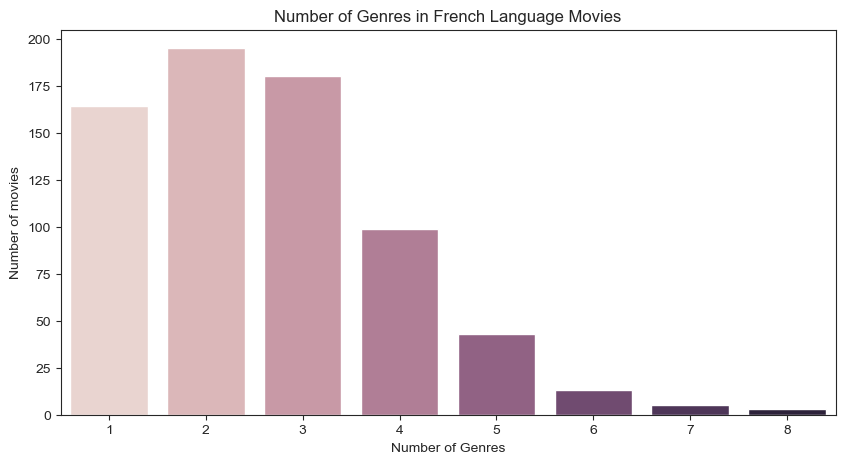

In [104]:
#Figure 11
#plot the graph using seaborn
# Create a figure and axes object
fig11, ax = plt.subplots(figsize=(10, 5))

#create the plot
ax=sns.barplot(
    data=genre_count2,
    x='genre_number',
    y='genre_count',
    hue='genre_number',
    legend=False)

#set the lable and title
ax.set(xlabel='Number of Genres', ylabel='Number of movies', title='Number of Genres in French Language Movies')

#show the plot
plt.show(fig11)

Both Method 1 and Method 2 have produced the same result with similar extent of coding. However with Method 2, we are able to provide which movies actually have more than one genre. For example see below for determing which movies have more than 6 genres.

In [105]:
#Filter for movies that have more than six genres and sort by genre_num
frenchmovies_greaterthansixgenres = genre_number_frenchmovies[genre_number_frenchmovies['genre_number']>=6].sort_values('genre_number')

#show dataframe
print(frenchmovies_greaterthansixgenres)

                                 Title  genre_number
635                        The Tourist             6
602                 The Pink Panther 2             6
55                    Asterix the Gaul             6
59           Atlantis: The Lost Empire             6
177                       Edison & Leo             6
215              Ghosts of Cité Soleil             6
503       The Ballad of Buster Scruggs             6
252                               Home             6
269                            Inferno             6
465       Slugterra: Ghoul from Beyond             6
464                          Slow West             6
404                        Phantom Boy             6
427                        Ratatouille             6
513                 The Brothers Grimm             7
289                             Kabala             7
606          The Princess and the Frog             7
240         Herbie Goes to Monte Carlo             7
186                 Ernest & Celestine        

## 4. Where is France placed compared to other countries with regard to the number of movies made overall?

For this question have used the 'new_movie_details3' dataframe that has the column 'primary_country' with the assumption that the first movie in the 'country' column is the where the movie was first made.
Note that counting all the movies was too many visually, so only included countries with more than 20 movies in the visual.

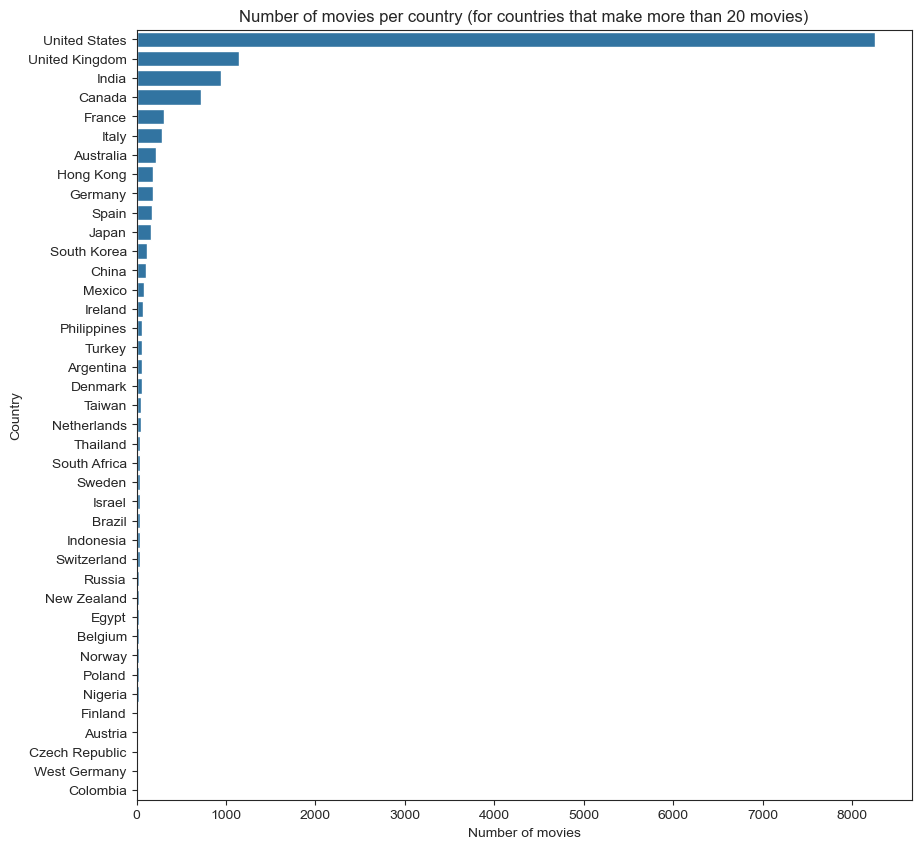

In [106]:
#Figure 12
#create a count plot usng seaborn
# Filter the DataFrame to include only countries with more than 20 movies
filtered_movies = new_movie_details3.groupby('Primary_Country').filter(lambda x: len(x) >= 20)
sorted_countries = filtered_movies['Primary_Country'].value_counts().index


# Create a figure and axes object
fig12, ax = plt.subplots(figsize=(10, 10))

#create plot
ax = sns.countplot(data=filtered_movies,
              y='Primary_Country',
             order=sorted_countries)

# Set the labels and title.
ax.set(xlabel='Number of movies', ylabel='Country', title='Number of movies per country (for countries that make more than 20 movies)')

#show plot
plt.show(fig12)


From the graph above France is in the top 10 movie producing countries, so will provide the top 10 only for the dashboard.

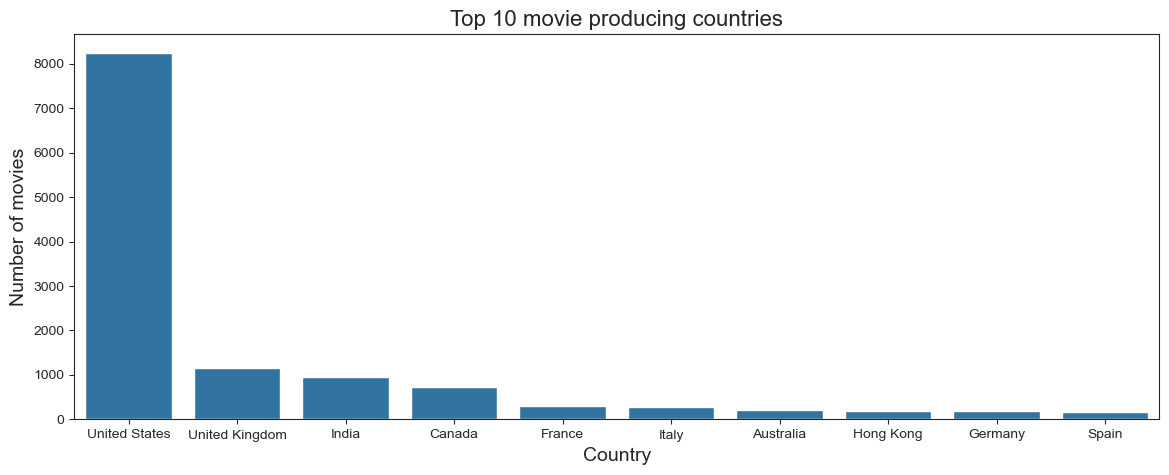

In [107]:
#Figure 13
#create a count plot usng seaborn
#sort by top 10 movies producing countries
sorted_countries = new_movie_details3['Primary_Country'].value_counts().nlargest(10).index


# Create a figure and axes object
fig13, ax = plt.subplots(figsize=(14, 5))

#create plot
ax = sns.countplot(data=new_movie_details3,
              x="Primary_Country",
             order=sorted_countries)

# Set the labels and title.
ax.set(xlabel='Country', ylabel='Number of movies', title='Top 10 movie producing countries')
ax.set_xlabel('Country', fontsize=14)
ax.set_ylabel('Number of movies', fontsize=14)
ax.set_title('Top 10 movie producing countries', fontsize=16)

#show plot
plt.show(fig13)

Top 10 producing movie producing countries are US, UK, India, Canada, France, Italy, Australia, Hong Kong, Germany and Spain. France comes 6th in the list.

It would also be interesting to view over time how many movies France has been making over the years.

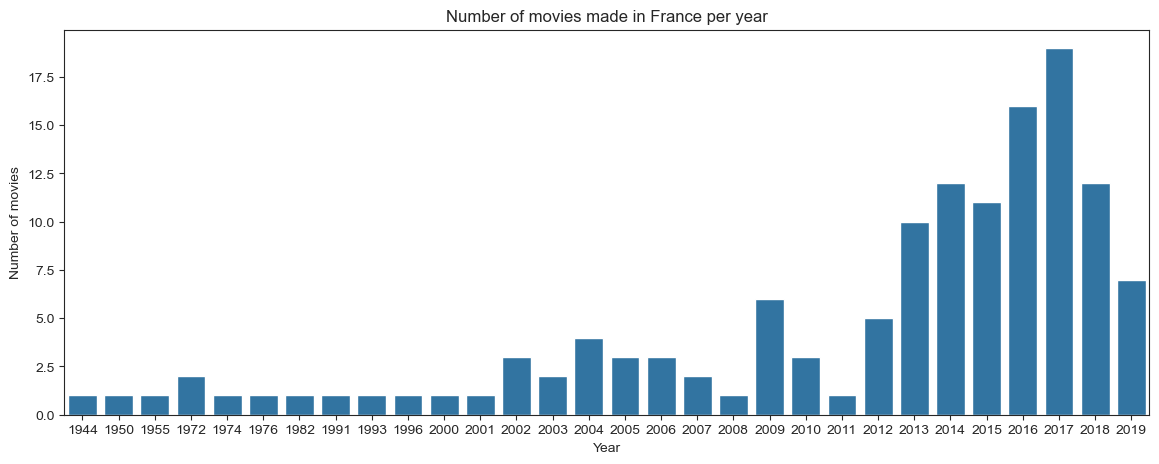

In [108]:
#Figure 14
#create a count plot usng seaborn

#Filter the dataframe for movies made in France only
france_movies = new_movie_details3[new_movie_details3['Country'] == 'France']

# Create a figure and axes object
fig14, ax = plt.subplots(figsize=(14, 5))

#create the plot
ax = sns.countplot(data=france_movies,
              x='Year')

# Set the labels and title.
ax.set(xlabel='Year', ylabel='Number of movies', title='Number of movies made in France per year')

#show the plot
plt.show(fig14)

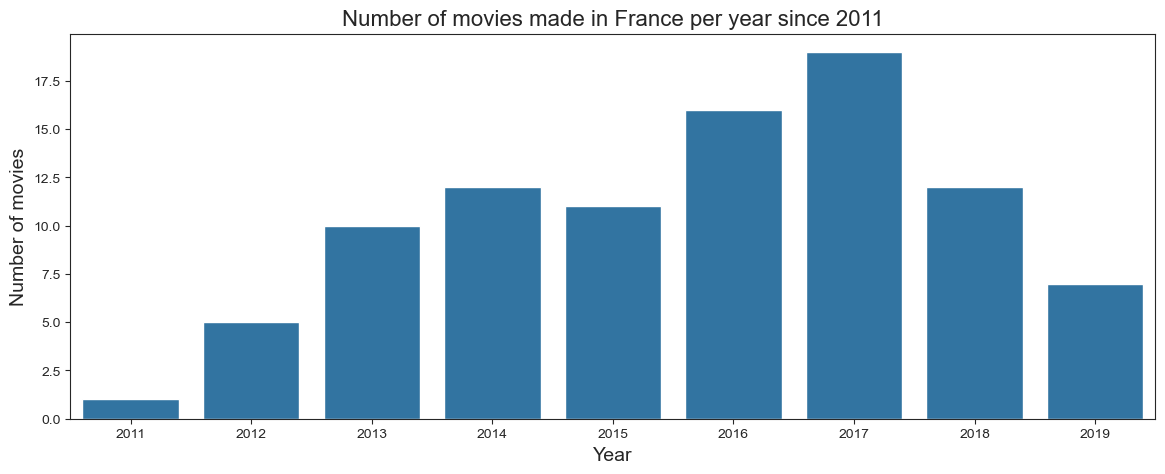

In [109]:
#Figure 15
#create a count plot usng seaborn
#Filter the dataframe for movies made in France only and from year 2011 onwards
france_movies = new_movie_details3[(new_movie_details3['Country'] == 'France') & (new_movie_details3['Year']>=2011)]

# Set the size of the plot
fig15, ax = plt.subplots(figsize=(14, 5))
sns.set_style("ticks")


#create plot
ax = sns.countplot(data=france_movies,
              x='Year')

# Set the labels and title.
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Number of movies', fontsize=14)
ax.set_title('Number of movies made in France per year since 2011', fontsize=16)

#show plot
plt.show(fig15)

From the visualisation above, since 2011, the number of movies that France made was steadily increasing until 2017 afterwhich they started to decline. 

## Bokeh interative plot
An interactive Bokeh graph with a year slider was also created, but it requires execution with a Bokeh server. To create this within the Notebook, a callback with HTML/JavaScript is needed, which has not been learnt at this time.

In [110]:
#save the new_movie_details3 dataframe
new_movie_details3.to_csv('new_movie_details3.csv')

In [111]:
#Figure 16 (this needs to be saved as a .py to be executed on bokeh server)
#import the Bokeh items required
import pandas as pd
from bokeh.io import curdoc
from bokeh.layouts import column
from bokeh.models import ColumnDataSource, Slider
from bokeh.plotting import figure

#import the dataset
new_movie_details3 = pd.read_csv('new_movie_details3.csv')

#Filter the dataframe for movies made in France only
france_movies = new_movie_details3[new_movie_details3['Country'] == 'France']

# Group by 'Year' and count the number of movies made each year (note this was not required for when using Seaborn)
movies_per_year = france_movies['Year'].value_counts().sort_index()

# Create a ColumnDataSource 
# this is required when using Bokeh to handle the data, where as with Seaborn, you can directly pass the pandas dataframe)
#Bokeh requires the ColumnDataSource that allows Bokeh to manage the data more efficiently and create interactive elements)
source = ColumnDataSource(data=dict(year=movies_per_year.index, count=movies_per_year.values))

# Create a new plot with a title and axis labels
plot = figure(title='Number of movies made in France per year', 
               x_axis_label='Year',
               y_axis_label='Number of Movies', 
               width=800, 
               height=400)

# Add a bar renderer with legend and bar width
plot.vbar(x='year', 
           top='count', 
           width=0.9, 
           source=source, 
           legend_label='Movies per year')

# Create a slider to filter the years
slider = Slider(start=1944, 
                     end=france_movies['Year'].max(), 
                     value=1944, 
                     step=1, 
                     title='Year')

# Define a callback function that updates the plot based on the slider value
def update(attr, old, new):
    year = slider.value
    new_data = {'year': [y for y in movies_per_year.index if y >= year], 
                'count': [movies_per_year[y] for y in movies_per_year.index if y >= year]}
    source.data = new_data
    
# Attach the callback to the slider
slider.on_change('value', update)

# Layout the plot and slider
fig16 = column(slider, plot)

# Add the layout to the current document
curdoc().add_root(fig16)

## 5. Is there a relationship between age groups and genres for french-language movies

In [112]:
#use the exploded_frenchmovies_genres dataframe that has split the genres into separate rows and filtered for french-language movies only.
#view the exploded_frenchmovies_genres and null values
print(exploded_frenchmovies_genres.info())
exploded_frenchmovies_genres.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 1842 entries, 31 to 15063
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Title      1842 non-null   object 
 1   Year       1842 non-null   int64  
 2   Age        1005 non-null   object 
 3   IMDb       1842 non-null   float64
 4   Directors  1822 non-null   object 
 5   Genres     1842 non-null   object 
 6   Country    1842 non-null   object 
 7   Language   1842 non-null   object 
 8   Runtime    1842 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 143.9+ KB
None


Title          0
Year           0
Age          837
IMDb           0
Directors     20
Genres         0
Country        0
Language       0
Runtime        0
dtype: int64

In [113]:
#check again unique values for age and genres
print(f"{'Number of unique Age groups'}: {exploded_frenchmovies_genres.Age.nunique()}")
print(f"{'Type of unique Age groups'}: {exploded_frenchmovies_genres.Age.unique()}")


print(f"{'Number of unique Genres'}: {exploded_frenchmovies_genres.Genres.nunique()}")
print(f"{'Type of unique Genres'}: {exploded_frenchmovies_genres.Genres.unique()}")

Number of unique Age groups: 5
Type of unique Age groups: [nan '18+' '7+' '13+' 'all' '16+']
Number of unique Genres: 23
Type of unique Genres: ['Documentary' 'Drama' 'Short' 'Comedy' 'Romance' 'History' 'War'
 'Biography' 'Sci-Fi' 'Crime' 'Fantasy' 'Mystery' 'Thriller' 'Action'
 'Adventure' 'Animation' 'Music' 'Horror' 'Family' 'Musical' 'News'
 'Western' 'Sport']


The ‘Age’ variable has 5 unique variables (All, 18+, 16+, 13+, 7+) confirming that it is a categorical variable. There were also quite a number of missing values for ‘Age’ (over 800) as seen in the previous output. There are too many missing data to remove these values. So for the purposes of this analysis, the missing ‘Age’ values were replaced with 18+ as didn’t want to run the risk of providing inappropriate movies to the age groups below 18 of age.

In [114]:
#set the categorical 'Age' into specified custom order
age_order = ['all', '18+', '16+', '13+', '7+']
exploded_frenchmovies_genres['Age'] = pd.Categorical(exploded_frenchmovies_genres['Age'], categories=age_order, ordered=True)

In [115]:
#Replace the missing 'Age' values with 18+
exploded_frenchmovies_genres.loc[:,'Age'] = exploded_frenchmovies_genres['Age'].fillna('18+')

#view the dataframe
print(exploded_frenchmovies_genres.info())
print(exploded_frenchmovies_genres.isnull().sum())
exploded_frenchmovies_genres.head()


<class 'pandas.core.frame.DataFrame'>
Index: 1842 entries, 31 to 15063
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   Title      1842 non-null   object  
 1   Year       1842 non-null   int64   
 2   Age        1842 non-null   category
 3   IMDb       1842 non-null   float64 
 4   Directors  1822 non-null   object  
 5   Genres     1842 non-null   object  
 6   Country    1842 non-null   object  
 7   Language   1842 non-null   object  
 8   Runtime    1842 non-null   float64 
dtypes: category(1), float64(2), int64(1), object(5)
memory usage: 131.5+ KB
None
Title         0
Year          0
Age           0
IMDb          0
Directors    20
Genres        0
Country       0
Language      0
Runtime       0
dtype: int64


,Title,Year,Age,IMDb,Directors,Genres,Country,Language,Runtime
31,Mystery of the Pink Dolphin,2015,18+,7.1,Eric Ellena,Documentary,"France,Brazil","French,English,Portuguese,Dutch",52.0
49,My Revolution,2016,18+,3.5,Ramzi Ben Sliman,Drama,France,French,80.0
54,The Story of the Twelve Apostles,1999,18+,6.6,Yanai Arfi,Documentary,United States,"English,French,Spanish",26.0
54,The Story of the Twelve Apostles,1999,18+,6.6,Yanai Arfi,Short,United States,"English,French,Spanish",26.0
78,Girl on a Bicycle,2013,18+,6.2,Jeremy Leven,Comedy,"Germany,France","English,French,German,Italian",101.0


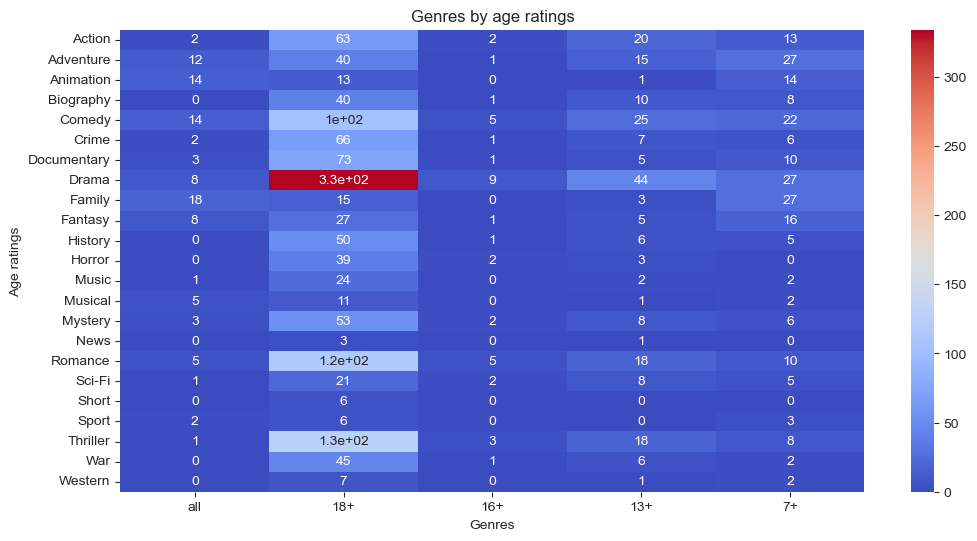

In [116]:
#Figure 17
#create a heatmap using seaborn

# Analyze genres and age ratings
age_genre_preferences = exploded_frenchmovies_genres.groupby('Age', observed=False)['Genres'].value_counts().unstack()

# Transpose the DataFrame to swap axes
age_genre_preferences = age_genre_preferences.T


# Create a figure and axes object
fig17, ax = plt.subplots(figsize=(12, 6))


# Create the heatmap using Seaborn
ax = sns.heatmap(data=age_genre_preferences, 
                 annot=True, cmap='coolwarm')

# Set the labels and title.
ax.set(xlabel='Genres', ylabel='Age ratings', title='Genres by age ratings')

#show the plot
plt.show(fig17)

Not completely content that using a heatmap is the best way to view the distribution of age and genre, although very quickly can tell that there over 300 movies made for 18+ for Drama. So below used a stacked bar chart using Seaborn.

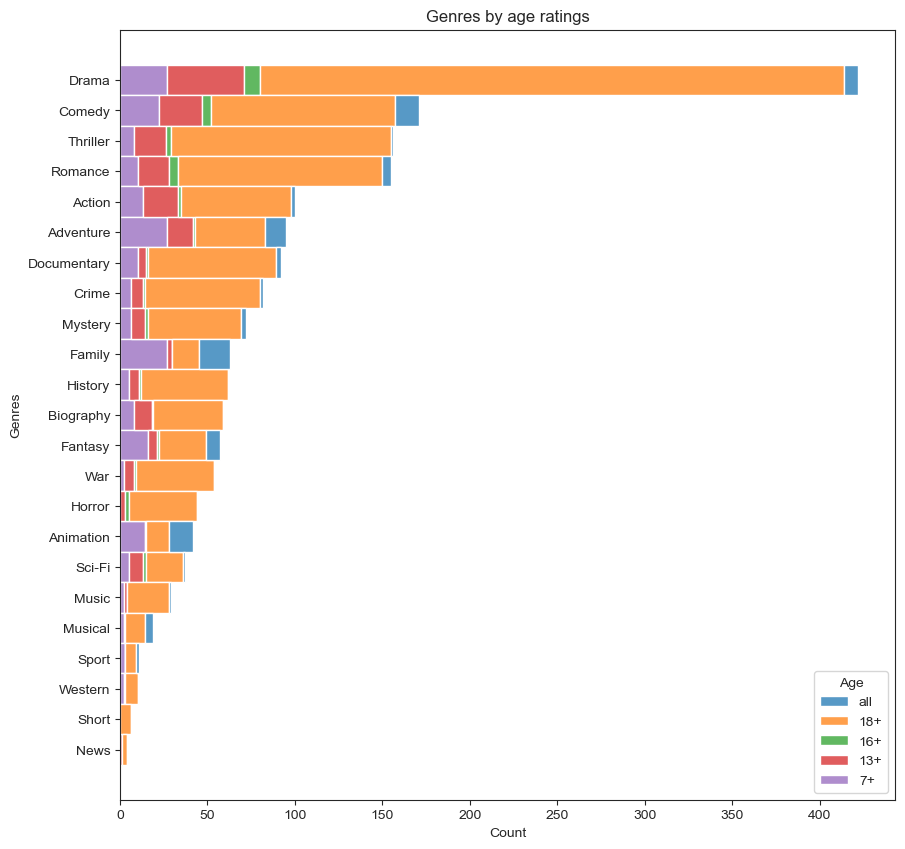

In [117]:
#Figure 18
# Analyze genres and age ratings via seaborn

# Calculate the count of movies for each genre so that i can sort them
genre_counts = exploded_frenchmovies_genres['Genres'].value_counts().reset_index()
genre_counts.columns = ['Genres', 'Count']

# Merge the counts back to the original DataFrame
exploded_frenchmovies_genres = exploded_frenchmovies_genres.merge(genre_counts, on='Genres')

# Sort the DataFrame by the count of movies
exploded_frenchmovies_genres = exploded_frenchmovies_genres.sort_values('Count', ascending=False)

# Create a figure and axes object
fig18, ax = plt.subplots(figsize=(10, 10))

#create the histplot, as it automatically counts the genres
ax = sns.histplot(data=exploded_frenchmovies_genres,
                  y='Genres',
                  hue='Age', 
                multiple='stack')

# Set the labels and title.
ax.set(ylabel='Genres', title='Genres by age ratings')


#show the plot
plt.show(fig18)

For better visualisation, created them side by side so top 10 and bottom 13 movies

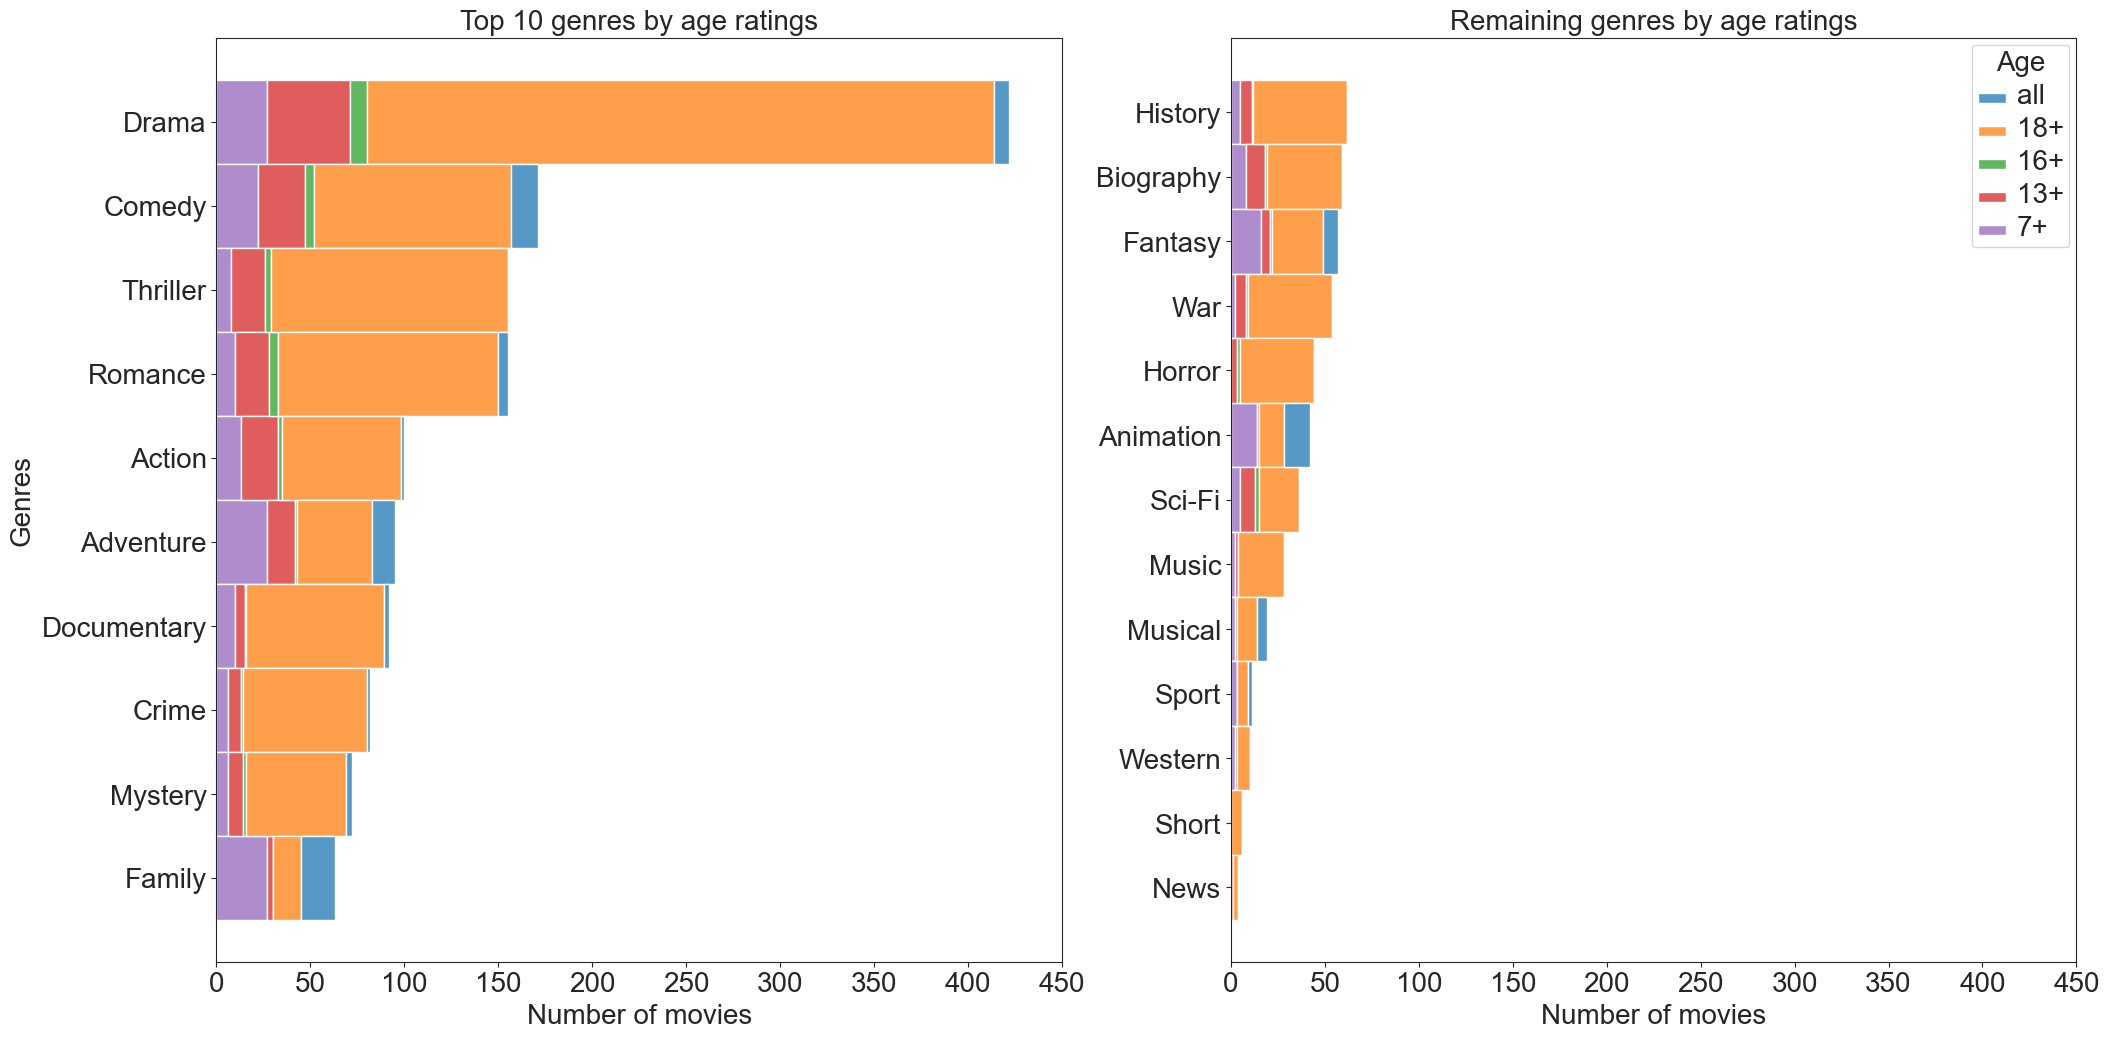

In [118]:
#Figure 19
# Split the DataFrame into top 10 genres and the rest
top_10_genres = exploded_frenchmovies_genres[exploded_frenchmovies_genres['Genres'].isin(genre_counts['Genres'][:10])]
remaining_genres = exploded_frenchmovies_genres[exploded_frenchmovies_genres['Genres'].isin(genre_counts['Genres'][10:])]


# Create a figure and axes object
fig19, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 12))


# Top 10 genres
sns.histplot(data=top_10_genres,
             y='Genres',
             hue='Age', 
             multiple='stack',
             ax=ax1)
ax1.set_xlabel('Number of movies', fontsize=20)
ax1.set_ylabel('Genres', fontsize=20)
ax1.set_title('Top 10 genres by age ratings', fontsize=20)
ax1.tick_params(axis='both', which='major', labelsize=20)
ax1.set_xlim(0, 450)  # Set x-axis limits
ax1.get_legend().remove()  # Remove the legend for ax1


# Remaining genres
sns.histplot(data=remaining_genres,
             y='Genres',
             hue='Age', 
             multiple='stack',
             ax=ax2)
ax2.set_xlabel('Number of movies', fontsize=20)
ax2.set_ylabel('')  # Remove y-axis label
ax2.set_title('Remaining genres by age ratings', fontsize=20)
ax2.tick_params(axis='both', which='major', labelsize=20)
ax2.set_xlim(0, 450)  # Set x-axis limits


# Access and modify the legend
legend = ax2.get_legend()
legend.set_title('Age')
plt.setp(legend.get_title(), fontsize='20')  # Set title font size
plt.setp(legend.get_texts(), fontsize='20')  # Set label font size


#show the plot
plt.show(fig19)


The figures above provides Canopy a better way to determine which movies and which genres Canopy movie makers need to make. More movies from History through to Westerns movies estpecilly for the over 13+ age group. 

## 6. What is the relationship between Runtime and IMDb rating for french-language and non-french language movies

As we noticed in the Q1 and Q2, there seemed to be a relationship between Runtime and IMDb. The following will be used to determine if such a relationship exists.

In [119]:
#use movie_details_french dataframe which is the cleaned dataset filted for french language movies only
#use movie_details_non_french dataframe which is the cleaned dataset filtered for non-french language movies

#view movie_details_french & movie_details_non_french dataframes
print(movie_details_french.info())
print(movie_details_non_french.info())


<class 'pandas.core.frame.DataFrame'>
Index: 702 entries, 31 to 15063
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Title      702 non-null    object 
 1   Year       702 non-null    int64  
 2   Age        342 non-null    object 
 3   IMDb       702 non-null    float64
 4   Directors  696 non-null    object 
 5   Genres     702 non-null    object 
 6   Country    702 non-null    object 
 7   Language   702 non-null    object 
 8   Runtime    702 non-null    float64
dtypes: float64(2), int64(1), object(6)
memory usage: 54.8+ KB
None
<class 'pandas.core.frame.DataFrame'>
Index: 13525 entries, 0 to 15068
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Title      13525 non-null  object 
 1   Year       13525 non-null  int64  
 2   Age        6155 non-null   object 
 3   IMDb       13525 non-null  float64
 4   Directors  13224 non-null  object 
 5   Ge

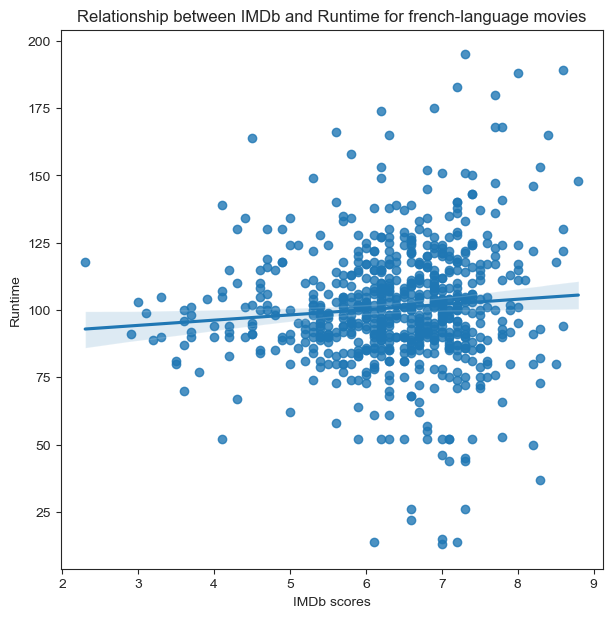

In [120]:
#Figure 20
#create a relationship plot for IMDb and Runtime for french-language movies using Seaborn


# Create a figure and axes object
fig20, ax = plt.subplots(figsize=(7, 7))

#create the plot
ax = sns.regplot(data=movie_details_french,
              x='IMDb',
              y='Runtime')

# Set the labels and title.
ax.set(xlabel='IMDb scores', ylabel='Runtime', title='Relationship between IMDb and Runtime for french-language movies')


plt.show(fig20)

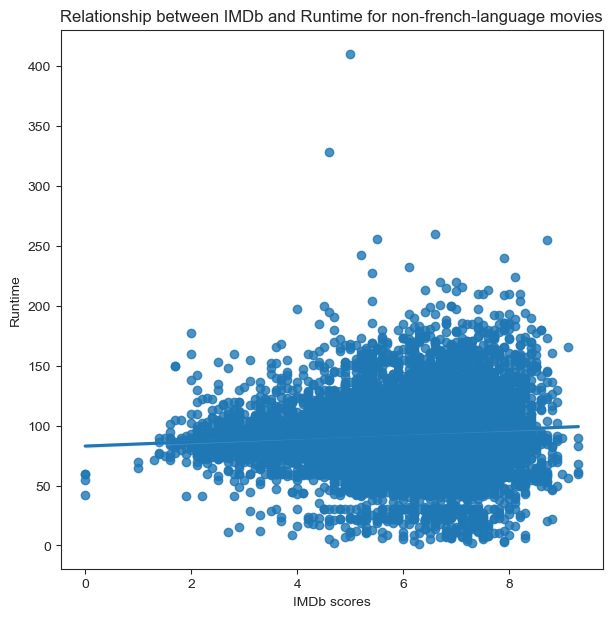

In [121]:
#Figure 21
#create a relationship plot for IMDb and Runtime for non-french language movies using Seaborn
fig21, ax = plt.subplots(figsize=(7, 7))


#create the plot
ax = sns.regplot(data=movie_details_non_french,
              x='IMDb',
              y='Runtime')

# Set the labels and title.
ax.set(xlabel='IMDb scores', ylabel='Runtime', title='Relationship between IMDb and Runtime for non-french-language movies')

#show the plot
plt.show(fig21)

The regression line seems to indicated that there is a very weak relationship between IMDb scores and Runtime for both french-language movies and non-french language movies, with longer movies associated with higher IMDb scores. However, viewing the figure, I dont feel a relationship does exist.

Although the relationship was very weak, I also wanted to explore if the relationship also depended on age.

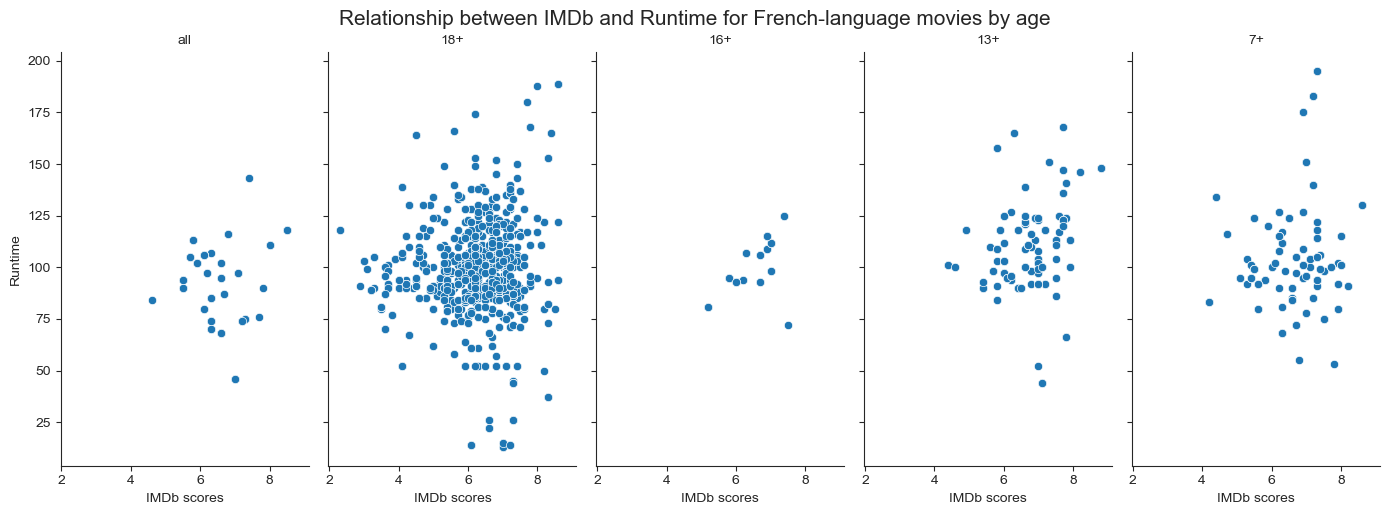

In [122]:
#Figure 22
#Used the exploded french language movies to determine this
#create a relationship plot for IMDb and Runtime for french-language movies using Seaborn and based on gender

# Create the relplot with specified figure size
fig22 = sns.relplot(data=exploded_frenchmovies_genres,
                x='IMDb',
                y='Runtime',
                col='Age',
                kind='scatter',
                height=5,  # Height of each subplot
                aspect=2.8/5)  # Aspect ratio of each subplot (width/height)

# Set the labels and title
fig22.set_axis_labels('IMDb scores', 'Runtime')
fig22.set_titles(col_template='{col_name}')
fig22.fig.suptitle('Relationship between IMDb and Runtime for French-language movies by age',
               y=1.02,
               fontsize=15)

# Show the plot
plt.show(fig22)

There does not seem to be a relationship IMDb scores and Runtime for different age ranges.

## Final visualisation to present to Canopy

### Visualisation for:
    1. Does France make longer movies on average based on the runtime?

    2. Does France make better movies on average based on the ratings?

In [123]:
#reshow Bokeh graph Figure 9
show(fig9)

3. Are there any french-language movies that claim to be of more than one genre?

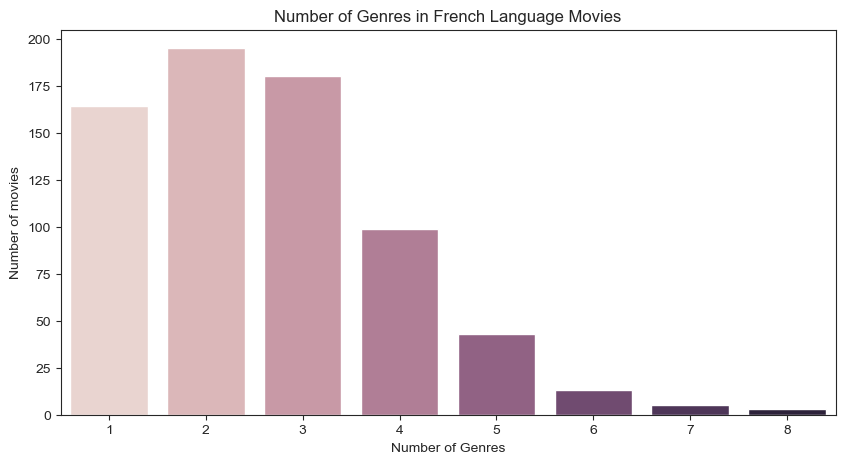

In [124]:
#Display Figure 11 that shows the number of genres in french-language movies
plt.figure(fig11)
plt.show(fig11)

4. Where is France placed compared to other countries with regard to the number of movies they make?

To display the graphs that I want to show Canopy with the Seaborn/Matplotlib graphs, unfortunately I need to recreate them within the same figure.


C:\Users\Dimi\AppData\Local\Temp\ipykernel_29064\2142261044.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=new_movie_details3,


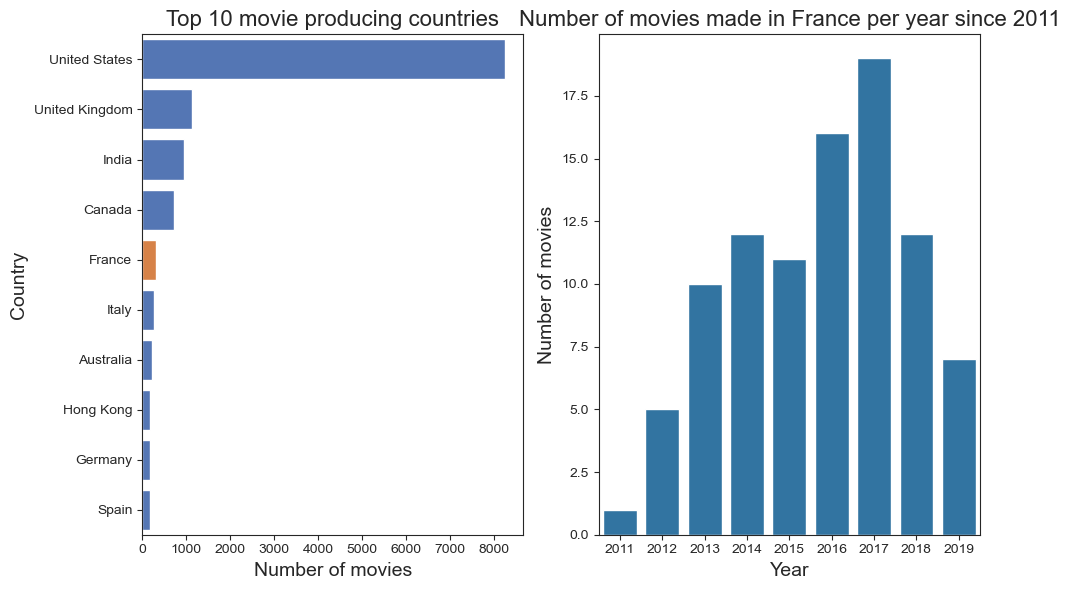

In [125]:
#Display Figures 13 and 15 side by side
#But will need to reproduce to display side by side in a dashboard
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# Create a custom color palette
palette = ['#ED7D31' if country == 'France' else '#4472C4' for country in sorted_countries]

#create Figure 10
sns.countplot(data=new_movie_details3,
              y='Primary_Country',
              order=sorted_countries,
              ax=axes[0],
              palette=palette,
              legend=False)

axes[0].set(xlabel='Country', ylabel='Number of movies', title='Top 10 movie producing countries')
axes[0].set_ylabel('Country', fontsize=14)
axes[0].set_xlabel('Number of movies', fontsize=14)
axes[0].set_title('Top 10 movie producing countries', fontsize=16)


#create Figure 12
france_movies = new_movie_details3[(new_movie_details3['Country'] == 'France') & (new_movie_details3['Year']>=2011)]
sns.countplot(data=france_movies,
              x='Year',
             ax=axes[1])

axes[1].set_xlabel('Year', fontsize=14)
axes[1].set_ylabel('Number of movies', fontsize=14)
axes[1].set_title('Number of movies made in France per year since 2011', fontsize=16)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

5. Is there a relationship between age groups and genres for french-language 

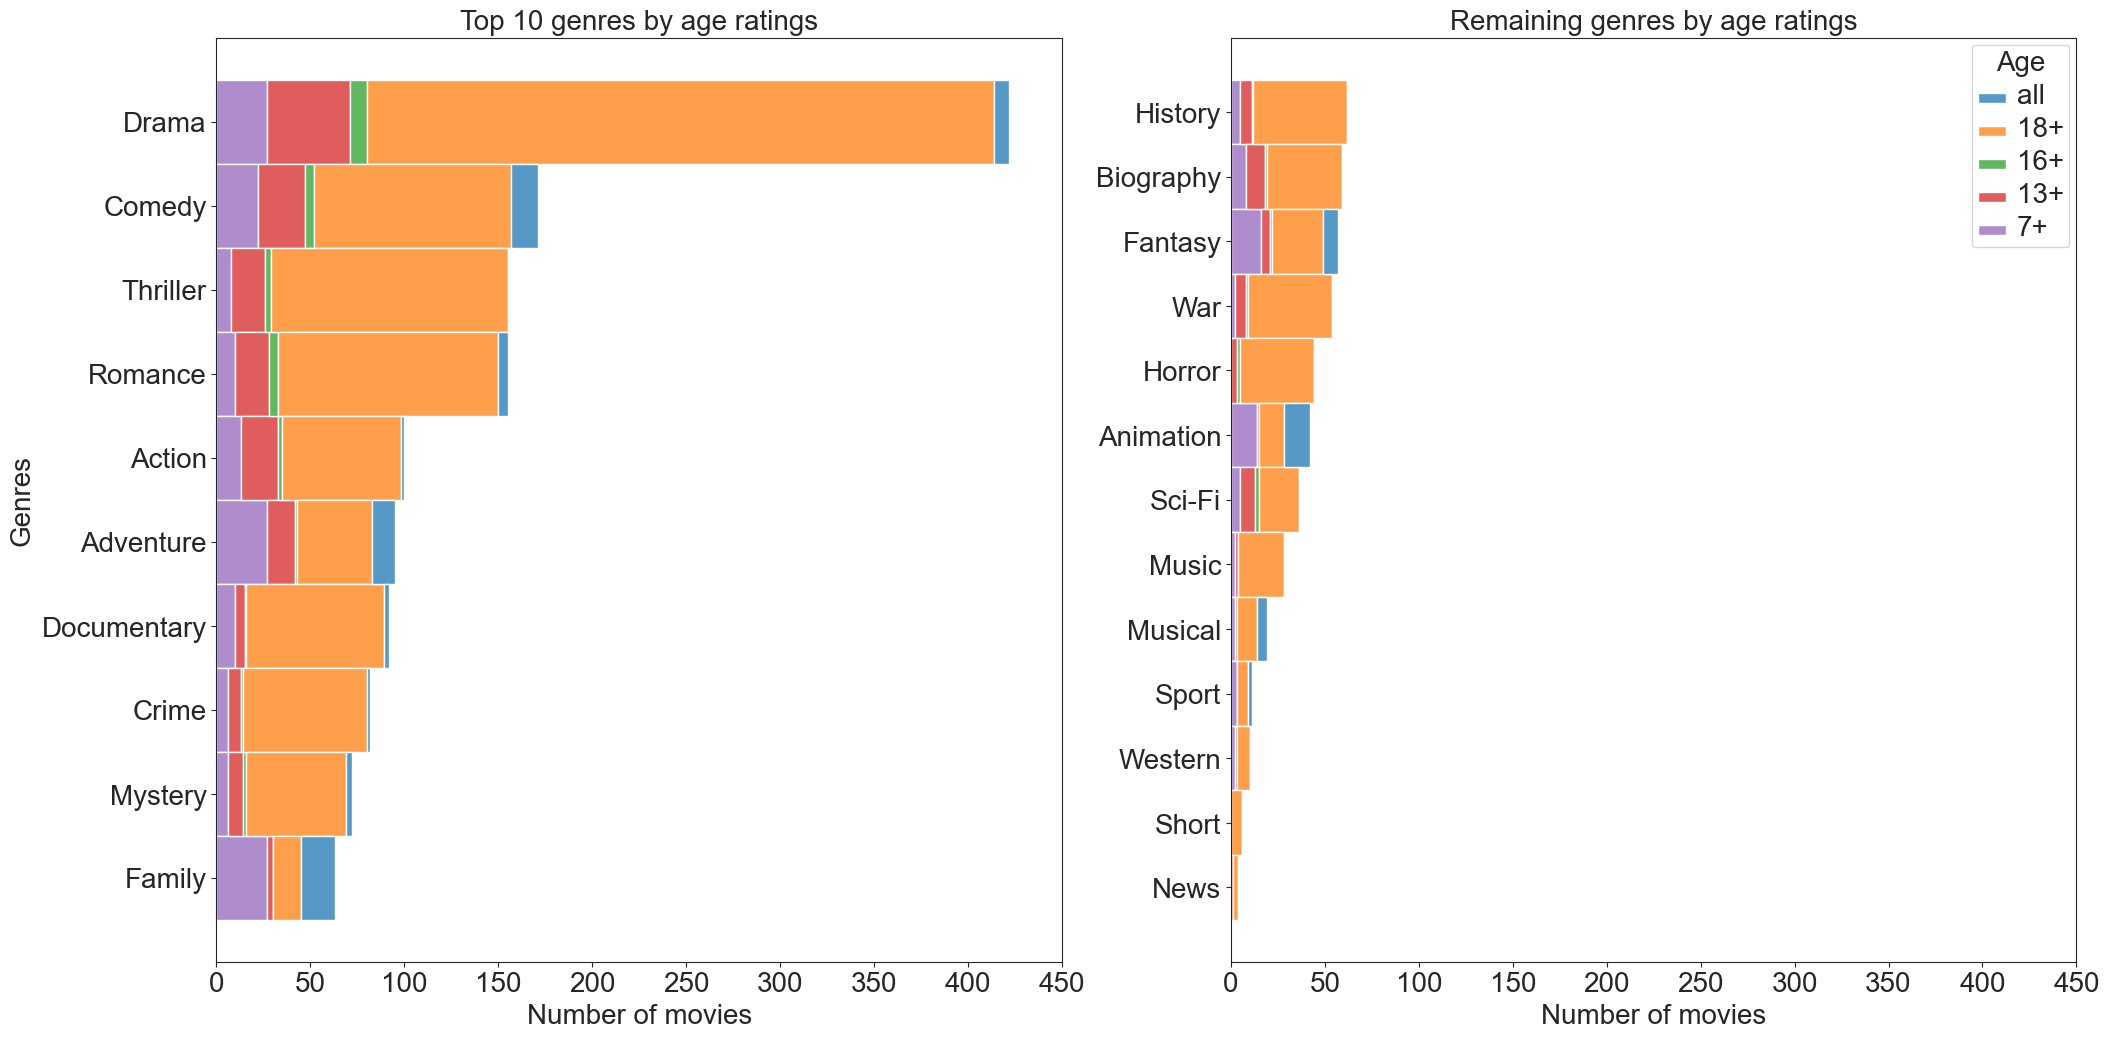

In [126]:
#Display Figure 19
plt.figure(fig19)
plt.show(fig19)

6. Is there a relationship between Runtime and IMDb rating for french-language movies?

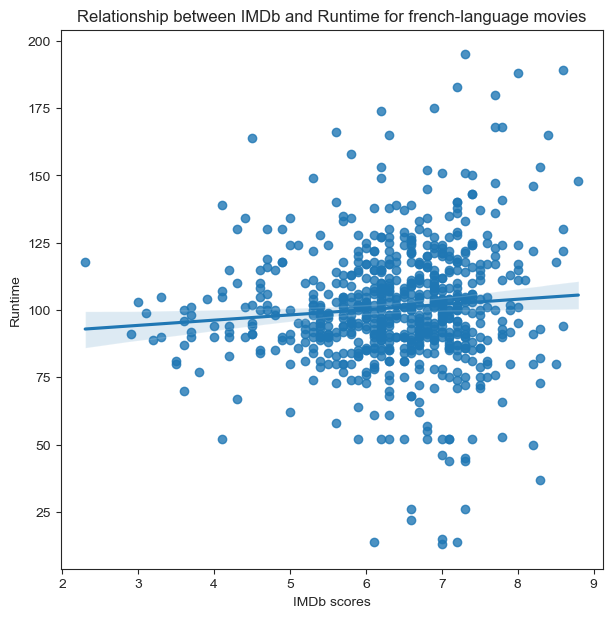

In [127]:
#Display Figure 20
plt.figure(fig20)
plt.show(fig20)